# ***Portugese Bank Marketing***

---


> **Business Problem**    
The banking sector plays a critical role in financial stability and economic growth, with customer acquisition being one of its primary objectives. Portuguese banks use telemarketing campaigns to promote term deposits, but the current approach targets a broad audience, resulting in **low conversion rates** and **high operational costs**. Inefficient targeting **wastes resources**, increases campaign expenses, and risks customer dissatisfaction. A **data-driven predictive solution** is needed to identify customers most likely to subscribe, **enabling smarter campaigns**, **reduced costs**, and **higher conversion rates**.

This project analyzes telemarketing campaign data from a Portuguese bank to predict which customers are likely to subscribe to a term deposit. Using machine learning algorithms including **Logistic Regression, K-Nearest Neighbors, Support Vector Machine,** and **Decision Tree**, the project benchmarks predictive performance and extracts actionable marketing insights to improve targeting, reduce campaign costs, and increase conversion rates.

# Domain Analysis
The dataset contains **customer demographics, contact history**, and **economic indicators** related to a Portuguese bank’s term deposit marketing campaigns. Key attributes include:


| Feature           | Description                                                                 |
|-------------------|-----------------------------------------------------------------------------|
| **age**           | Age of the customer (numeric).                                             |
| **job**           | Type of job (e.g., admin, technician, retired).                           |
| **marital**       | Marital status (married, single, divorced, unknown).                      |
| **education**     | Education level (basic, high school, university, etc.).                   |
| **default**       | Has credit in default? (yes, no, unknown).                                |
| **housing**       | Has a housing loan? (yes, no, unknown).                                   |
| **loan**          | Has a personal loan? (yes, no, unknown).                                  |
| **contact**       | Contact communication type (cellular, telephone).                         |
| **month**         | Last contact month of the year (e.g., may, jun, jul, aug, etc.).          |
| **day_of_week**   | Last contact day of the week (mon, tue, wed, thu, fri).                   |
| **duration**      | Last contact duration in seconds (numeric).                               |
| **campaign**      | Number of contacts during the current campaign.                           |
| **pdays**         | Days since the client was last contacted (-1 means never contacted).      |
| **previous**      | Number of contacts before this campaign.                                  |
| **poutcome**      | Outcome of the previous marketing campaign (success, failure, nonexistent).|
| **emp.var.rate**  | Employment variation rate (quarterly indicator).                          |
| **cons.price.idx**| Consumer Price Index (monthly indicator).                                  |
| **cons.conf.idx** | Consumer Confidence Index (monthly indicator).                             |
| **euribor3m**     | Euribor 3-month rate (daily indicator).                                    |
| **nr.employed**   | Number of employees (quarterly indicator).                                  |
| **y (target)**    | Has the client subscribed to a term deposit? (yes or no).                 |


# Importing Dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Loading the dataset
The dataset(bank-additional-full.csv) contains **41,188 records** and **21 attributes** related to telemarketing campaigns of a Portuguese bank, aiming to predict whether a customer subscribes to a term deposit. It includes **customer demographics, contact details, campaign history,** and **macroeconomic indicators**.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data=pd.read_csv("/content/drive/MyDrive/DataMites/Capstone-Projects/Portugese-Bank/bank-additional-full.csv",sep=";")

In [5]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


# Basic Checks

In [6]:
pd.set_option('display.max_columns', None)

In [7]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [11]:
data.describe(include='O')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


# Automated EDA Report

In [106]:
from ydata_profiling import ProfileReport
profile = ProfileReport(data, title="EDA Report", explorative=True)
profile.to_file("EDA_Report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 16.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [105]:
from google.colab import files
files.download("EDA_Report.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Exploratory Data Analysis

**Categorical Features**

In [14]:
cat_data=data.select_dtypes(include='O')
cat_data.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [15]:
#Getting unique categorical features
for i in cat_data:
    print(i,cat_data[i].unique())
    print(cat_data[i].value_counts())
    print("----------------------------------------------------------------------------------")

job ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
----------------------------------------------------------------------------------
marital ['married' 'single' 'divorced' 'unknown']
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
----------------------------------------------------------------------------------
education ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
education
university.degree      12168
high.school             9515
basic.9y                6

**Statistical measures of categorical data**

In [16]:
cat_data.describe(include='O').T

,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


**Numerical Features**

In [17]:
num_data = data.select_dtypes(include=['int64','float64'])
num_data.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [18]:
#Getting unique numerical features
for i in num_data:
    print(i,num_data[i].unique())
    print(num_data[i].value_counts())
    print("----------------------------------------------------------------------------------")

age [56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
91       2
98       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64
----------------------------------------------------------------------------------
duration [ 261  149  226 ... 1246 1556 1868]
duration
85      170
90      170
136     168
73      167
124     164
       ... 
1356      1
1103      1
1992      1
3183      1
1399      1
Name: count, Length: 1544, dtype: int64
----------------------------------------------------------------------------------
campaign [ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56
 39 35 42 28 26 27 32 21 24 29 31 30 41 37 40 33 34 43]
campaign
1     17642
2     10570
3      5341
4      2651
5      

**Statistical measures of numerical data**

In [19]:
num_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


**Univariate Analysis**

**Univariate Analysis for Categorical data**

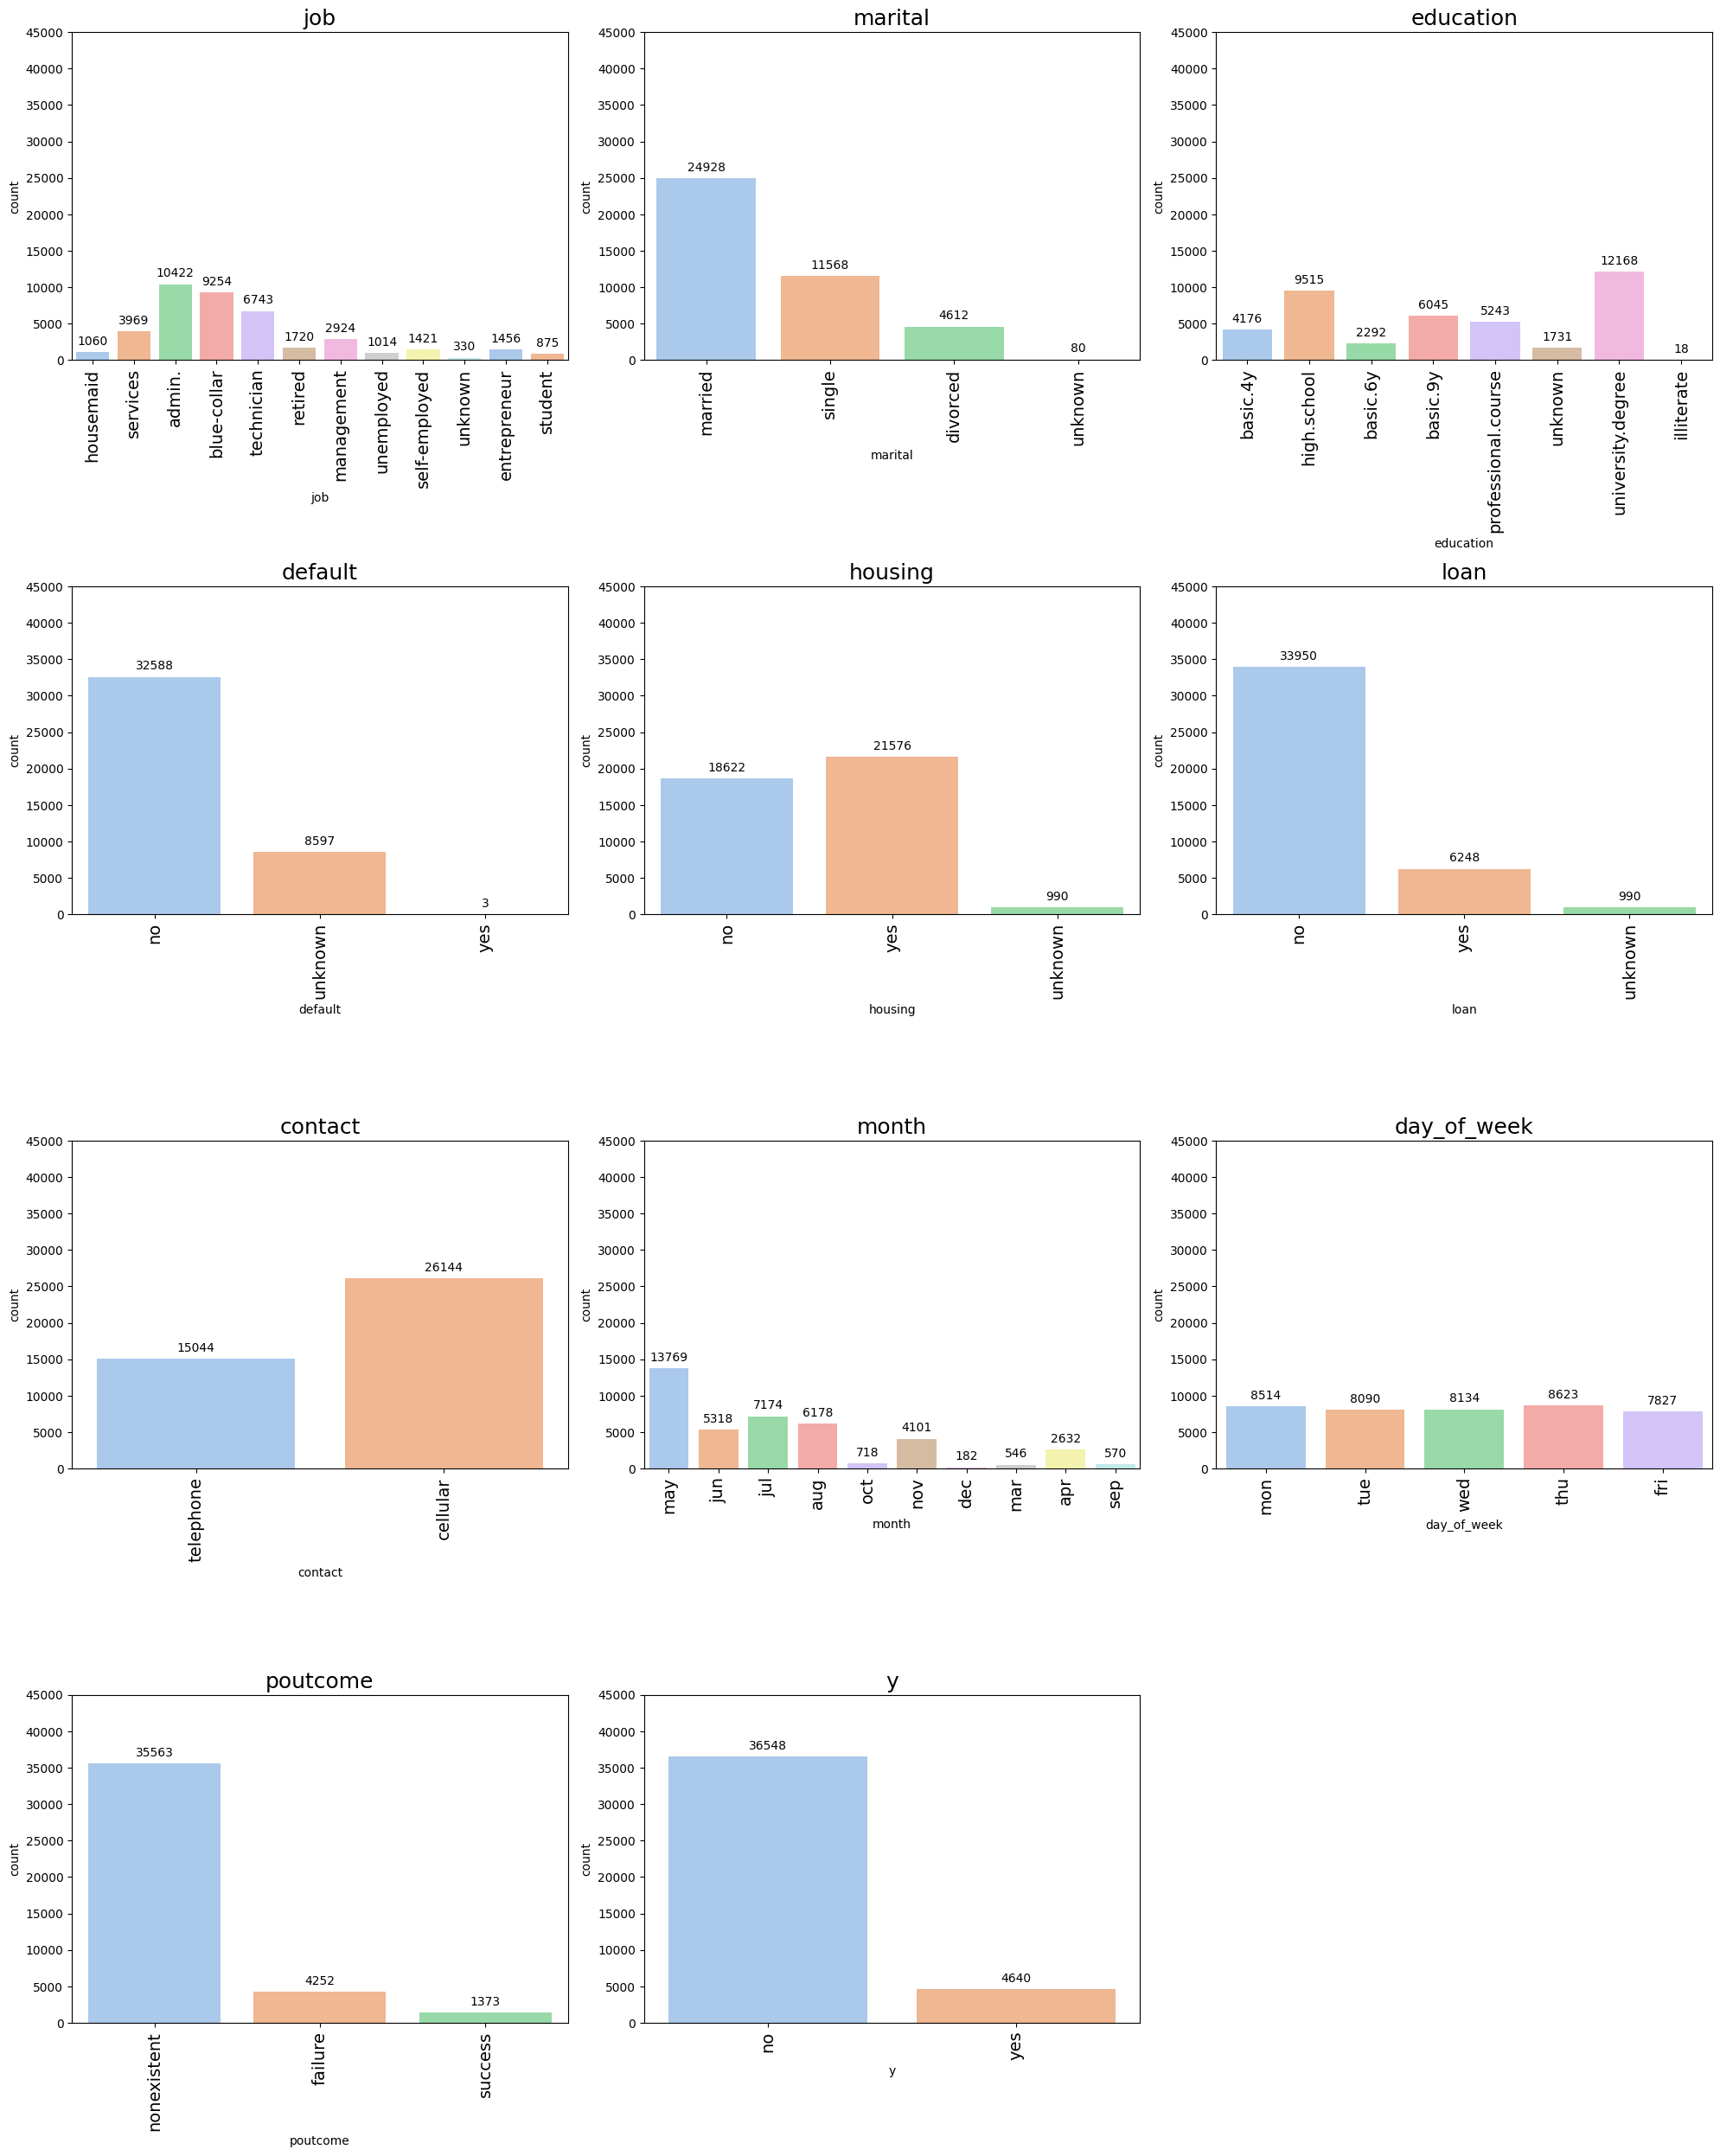

In [20]:
plt.figure(figsize=(20, 30))
plotno = 1
for i in cat_data:
    if plotno <= 17:
        plt.subplot(5, 3, plotno)
        ax = sns.countplot(x=cat_data[i], hue=cat_data[i], palette='pastel', legend=False)
        plt.ylim(0, 10000)
        plt.yticks(range(0, 50000, 5000))
        plt.xticks(rotation=90, fontsize=14)
        plt.title(f"{i}", fontsize=18)

        # Add value labels on top of bars
        for p in ax.patches:
            height = p.get_height()
            if height > 0:  # avoid labeling zero-height bars
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    height + 1000,  # above the bar
                    f'{int(height)}',
                    ha='center',
                    fontsize=10,
                    color='black'
                )
        plotno += 1
plt.tight_layout()
plt.show()

**Categorical Feature Distribution Insights**
<h5>
<details>
<summary>Job</summary>

- Most customers are **blue-collar**, followed by **management**, **technician**, and **admin**.
- Least represented: **student**, **housemaid**, and **unknown**.

</details>

<details>
<summary>Marital</summary>

- Majority are **married**, then **single**, and fewer **divorced**.
- Very few **unknown** entries.

</details>

<details>
<summary>Education</summary>

- Most have **university degree**, followed by **high school** and **basic education (9y)**.
- Very few **illiterate** or **unknown**.

</details>

<details>
<summary>Default</summary>

- Almost all customers have **no credit default**.
- Very few **unknown** or **yes** cases.

</details>

<details>
<summary>Housing Loan</summary>

- Majority have a **housing loan (~21K)**, but a significant portion does not (~18K).
- Minimal **unknown** values.

</details>

<details>
<summary>Personal Loan</summary>

- Most customers do **not** have a personal loan.
- Small percentage have a loan.

</details>

<details>
<summary>Contact Type</summary>

- Most contacts were made via **cellular**.
- Fewer contacts via **telephone**.

</details>

<details>
<summary>Month of Last Contact</summary>

- Peak in **May**, followed by **August** and **July**.
- Lowest in **March, September, and December**.

</details>

<details>
<summary>Day of Week</summary>

- Fairly balanced across weekdays.
- **Thursday** slightly higher than other days.

</details>

<details>
<summary>Previous Campaign Outcome (poutcome)</summary>

- Most were **nonexistent** (never contacted before).
- Few **failures**, very few **success**.

</details>

<details>
<summary>Target Variable (y)</summary>

- Highly imbalanced: Majority **No (~36K)**, only **~4.6K Yes**.
- Indicates need for **handling imbalance (SMOTE, class weights)**.

</details>
</h5>

**Univariate Analysis for Numerical data**

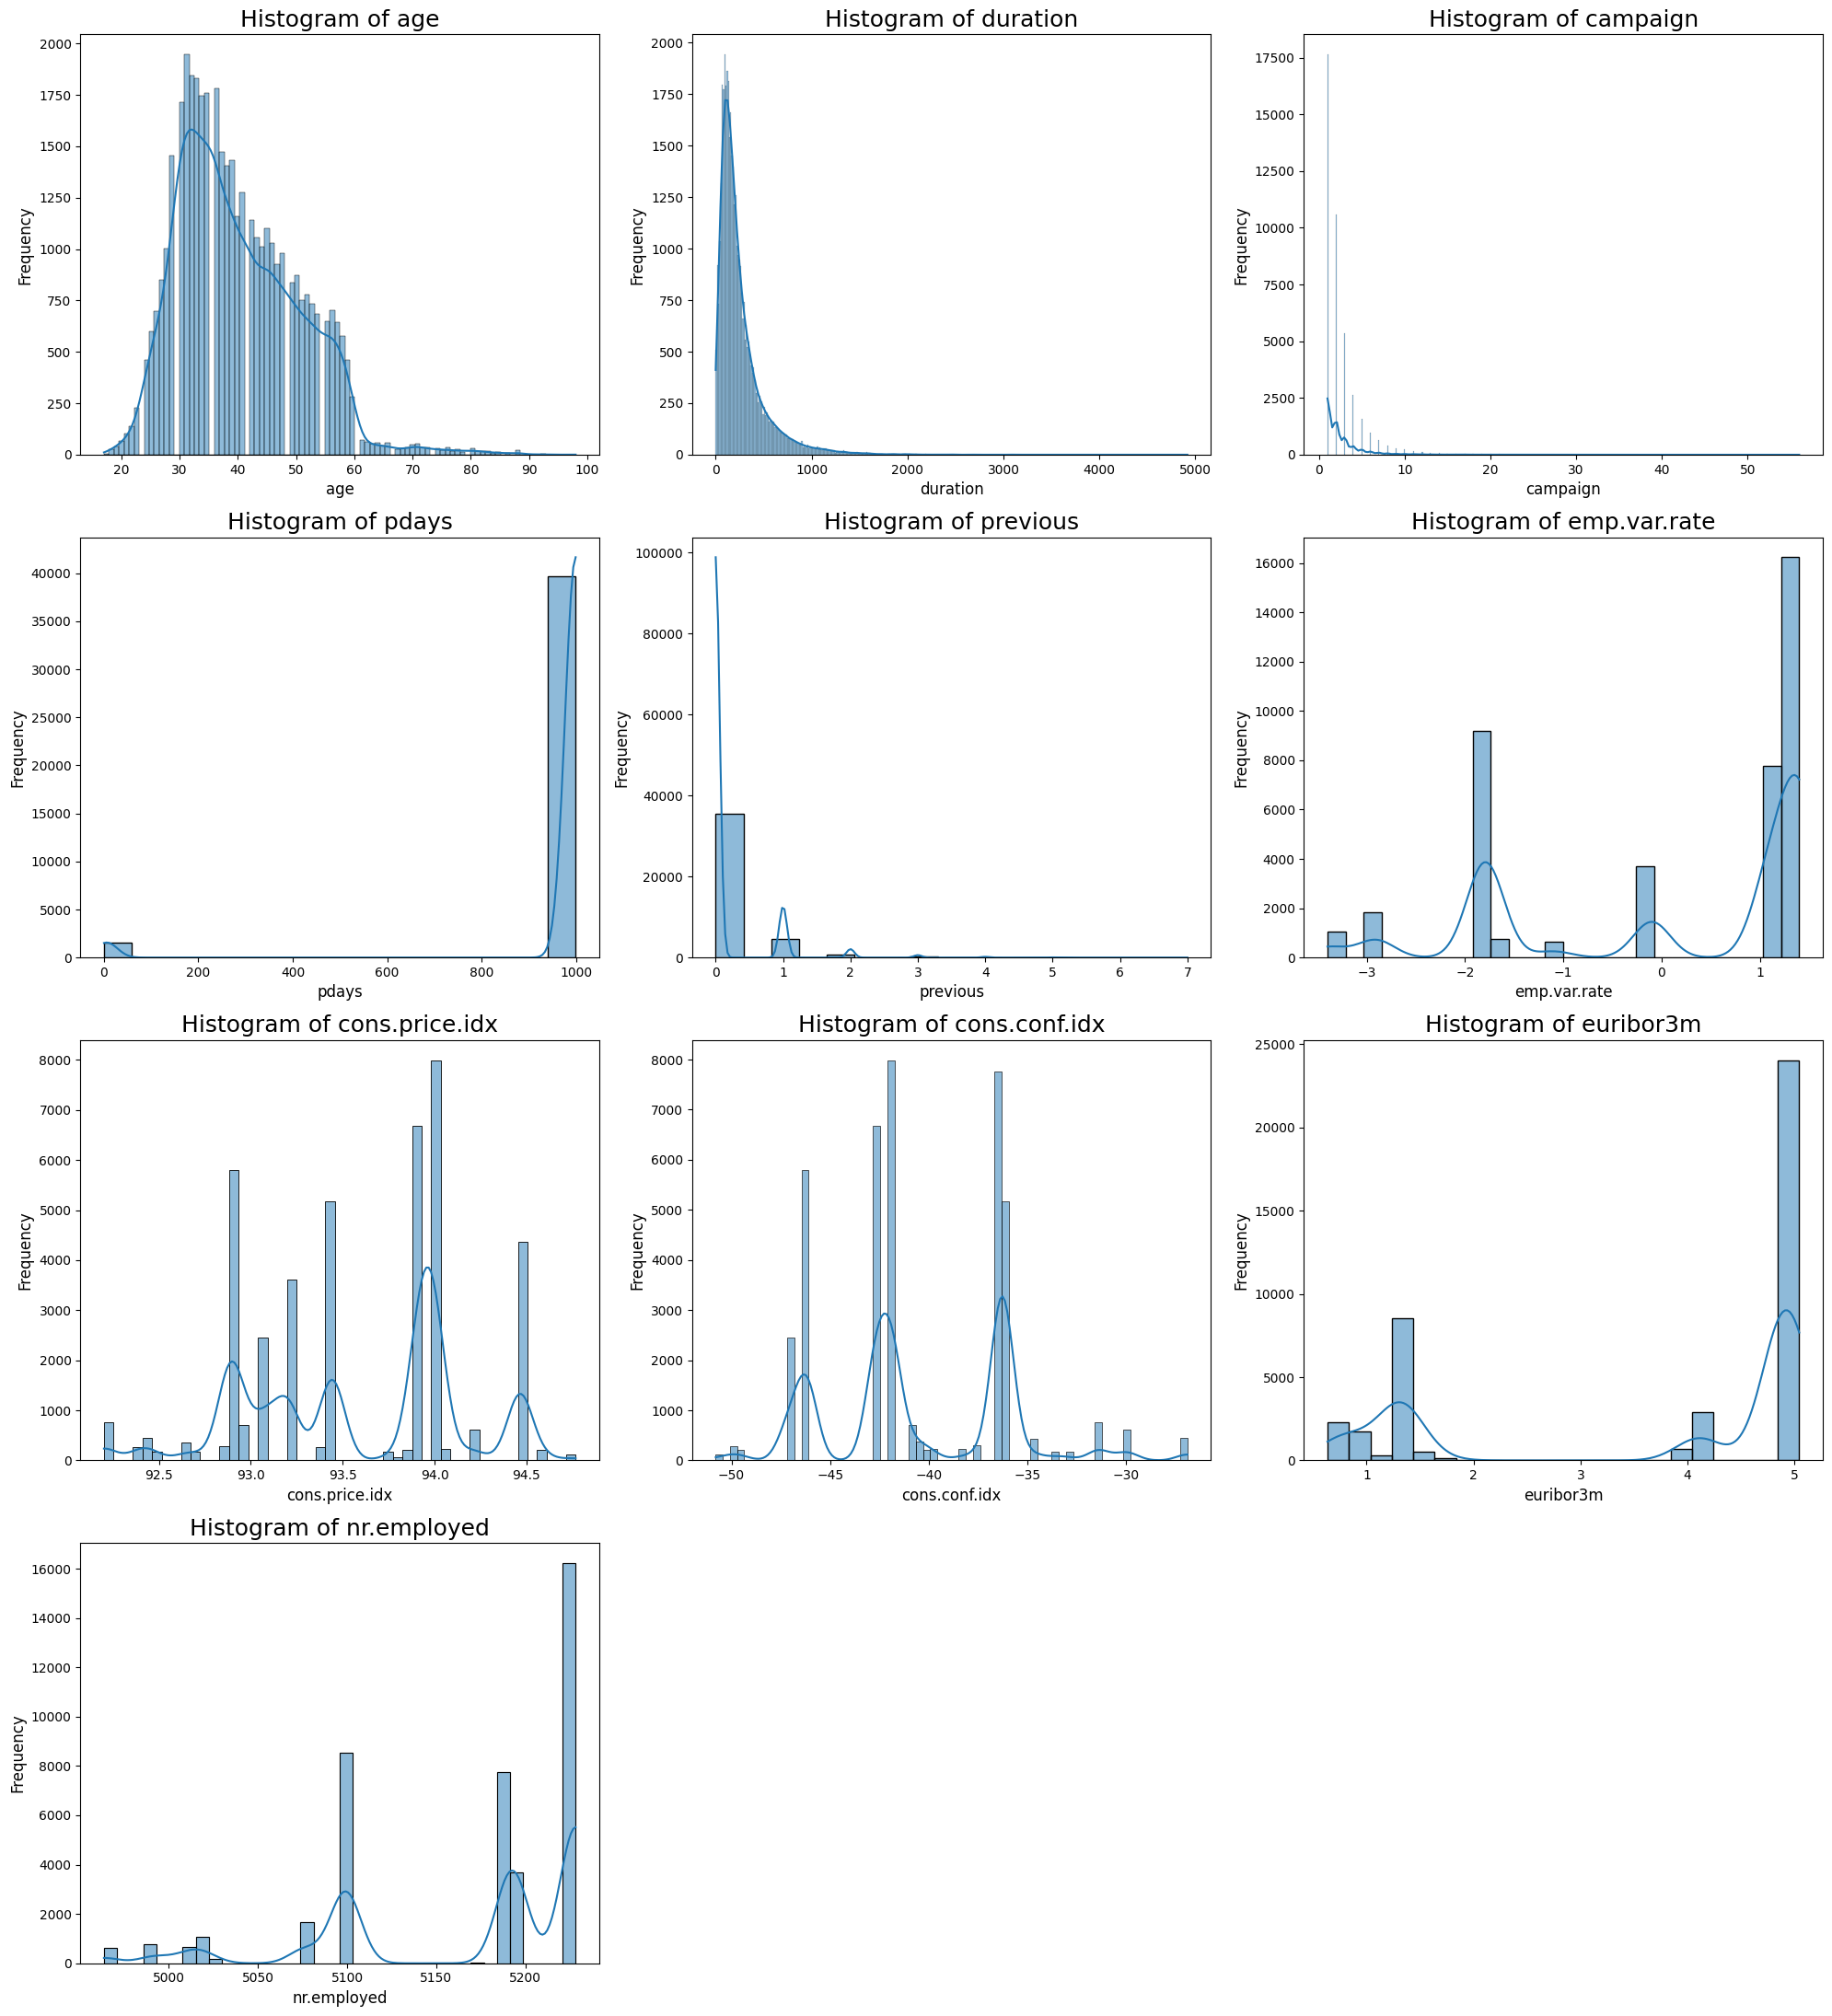

In [21]:
import math
plt.figure(figsize=(20, 22))
plotno = 1
cols_per_row = 3
total_cols = len(num_data.columns)

for col in num_data:
    plt.subplot(math.ceil(total_cols / cols_per_row), cols_per_row, plotno)
    sns.histplot(num_data[col], kde=True)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Histogram of {col}', fontsize=18)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plotno += 1

plt.tight_layout()
plt.show()

**Numerical Feature Insights**
<h5>
<details>
<summary>Age</summary>

- Most customers are between **30–40 years old**, with a peak around **35 years**.
- Very few customers are above **70 years**.

</details>

<details>
<summary>Duration</summary>

- **Highly right-skewed**: Most calls last under **300 seconds**.
- Very few calls last longer than **1000 seconds**.

</details>

<details>
<summary>Campaign</summary>

- Majority of customers were contacted **1–3 times**.
- Very few were contacted more than **10 times**.

</details>

<details>
<summary>Pdays</summary>

- **Huge spike at 999** → Indicates customers who were **never contacted previously**.
- A few customers were contacted recently (**< 100 days**).

</details>

<details>
<summary>Previous</summary>

- Most customers have **0 previous contacts**.
- Very few have more than **1 previous contact**.

</details>

<details>
<summary>Employment Variation Rate (emp.var.rate)</summary>

- Peaks around **1.1** and **-1.8**, indicating different economic cycles.
- Most values cluster around **-1 to 1**.

</details>

<details>
<summary>Consumer Price Index (cons.price.idx)</summary>

- Multiple peaks, mostly between **92 and 94**.
- Indicates different inflationary phases during campaigns.

</details>

<details>
<summary>Consumer Confidence Index (cons.conf.idx)</summary>

- Peaks near **-40** and **-45**, showing consumer pessimism during campaigns.
- Very few values above **-35**.

</details>

<details>
<summary>Euribor 3-Month Rate (euribor3m)</summary>

- Most values are around **4–5**.
- Sharp decline below **1.5** is rare.

</details>

<details>
<summary>Number of Employees (nr.employed)</summary>

- Peaks around **5000, 5100, and 5200**.
- Reflects changes in employment trends.

</details>
</h5>

**Bivariate Analysis**

**Bivariate Analysis for Categorical data**

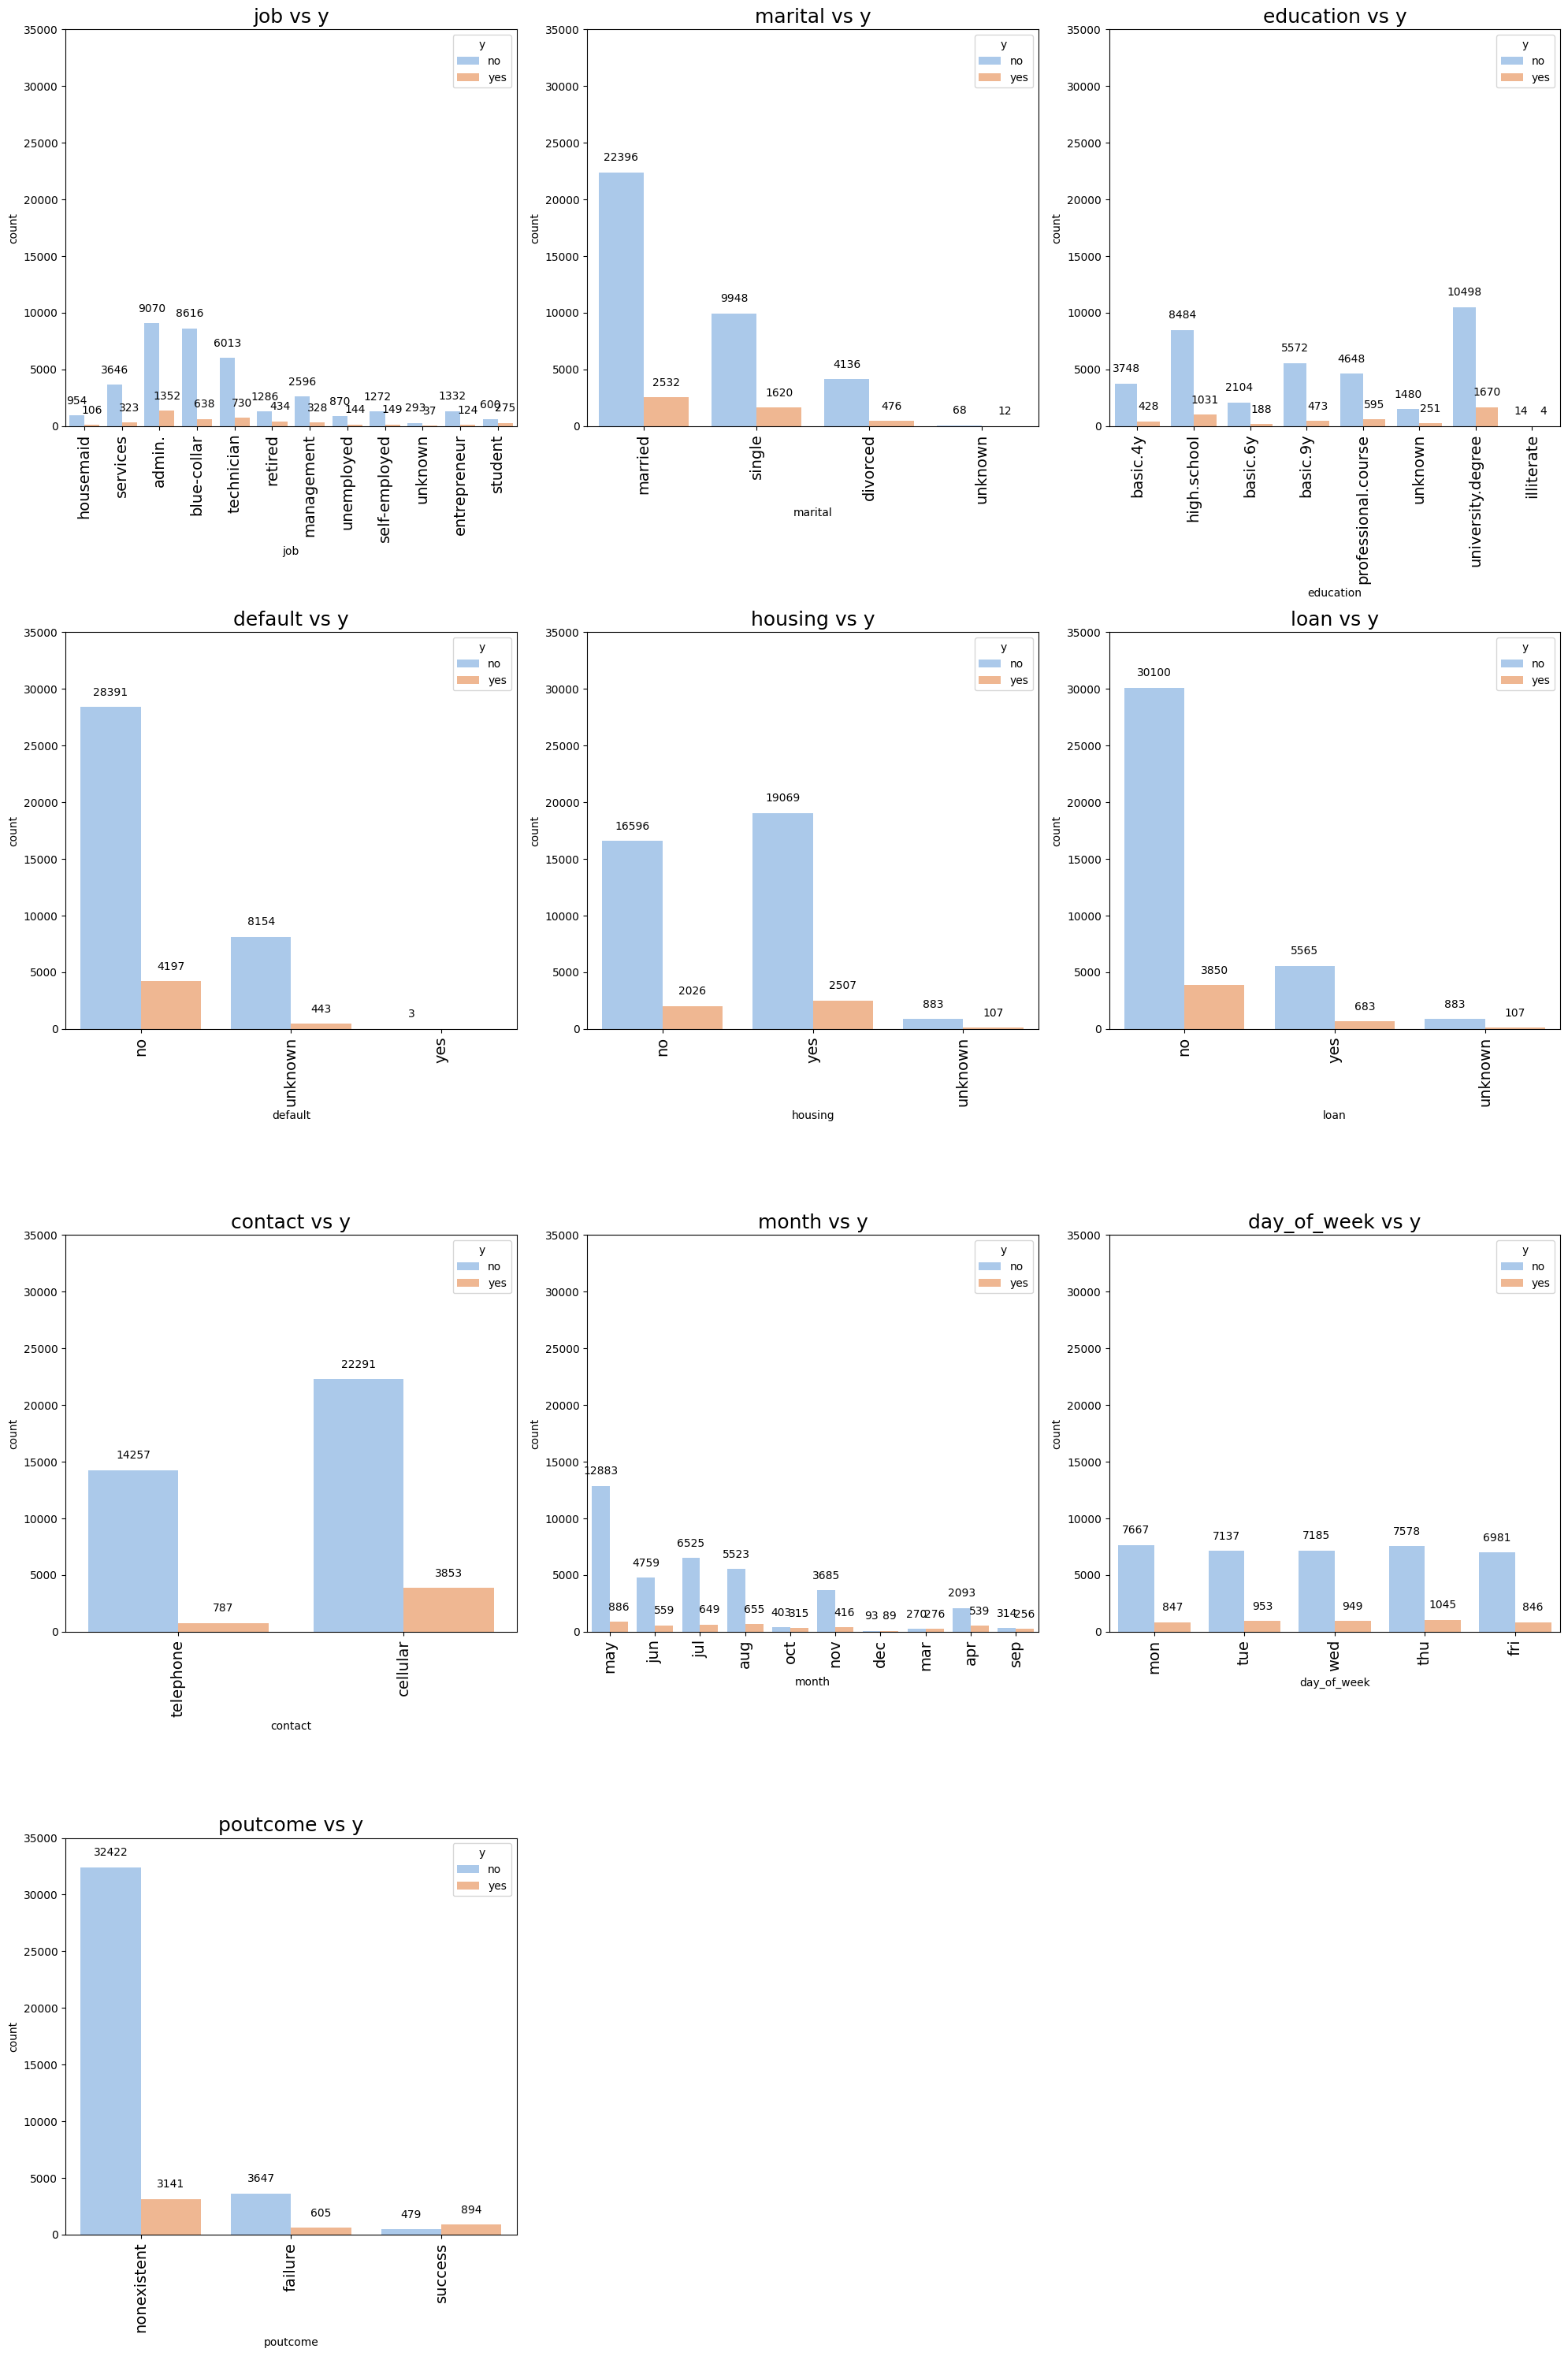

In [22]:
plt.figure(figsize=(20, 30))
plotno = 1
target = 'y'  # Replace this with your actual target variable if it's different

for i in cat_data.columns:
    if i != target and plotno <= 17:
        plt.subplot(4, 3, plotno)
        ax = sns.countplot(x=cat_data[i], hue=cat_data[target], palette='pastel')
        plt.ylim(0, 10000)
        plt.yticks(range(0, 40000, 5000))
        plt.xticks(rotation=90, fontsize=14)
        plt.title(f"{i} vs {target}", fontsize=18)

        # Add value labels on top of bars
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    height + 1000,
                    f'{int(height)}',
                    ha='center',
                    fontsize=10,
                    color='black'
                )
        plotno += 1

plt.tight_layout()
plt.show()

**Bivariate Analysis (Categorical vs Target `y`)**
<h5>
<details>
<summary>Job vs y</summary>

- **Student, retired, and unemployed** categories have higher conversion rates (more `yes` relative to `no`).
- Blue-collar and services have low term deposit subscription.

</details>

<details>
<summary>Marital vs y</summary>

- **Single customers** have a slightly higher subscription rate compared to married and divorced.
- Married customers dominate the dataset but have lower conversion.

</details>

<details>
<summary>Education vs y</summary>

- **University degree and professional course** holders show better subscription rates.
- Lower subscription among basic education and unknown categories.

</details>

<details>
<summary>Default vs y</summary>

- Customers with **no default** are more likely to subscribe.
- Very few with defaults subscribed.

</details>

<details>
<summary>Housing vs y</summary>

- **Customers without a housing loan** show higher subscription rates.
- Those with a housing loan have fewer subscriptions.

</details>

<details>
<summary>Loan vs y</summary>

- Customers without a personal loan show better conversion.
- Having a personal loan correlates with lower likelihood of term deposit subscription.

</details>

<details>
<summary>Contact vs y</summary>

- **Cellular contact** results in much higher subscription than telephone.
- Telephone contact shows low success rate.

</details>

<details>
<summary>Month vs y</summary>

- Campaigns in **March, September, December** have higher success ratios (more `yes` compared to total calls).
- **May** has the highest volume of calls but lower conversion.

</details>

<details>
<summary>Day of Week vs y</summary>

- Subscription is fairly balanced across weekdays.
- Slightly higher conversion on **Tuesday and Thursday**.

</details>

<details>
<summary>Poutcome vs y</summary>

- **Previous success** strongly correlates with subscription (customers with prior success are much more likely to subscribe again).
- Most customers have **nonexistent** prior contacts, with low conversions.

</details>
</h5>

**Bivariate Analysis for Numerical data**

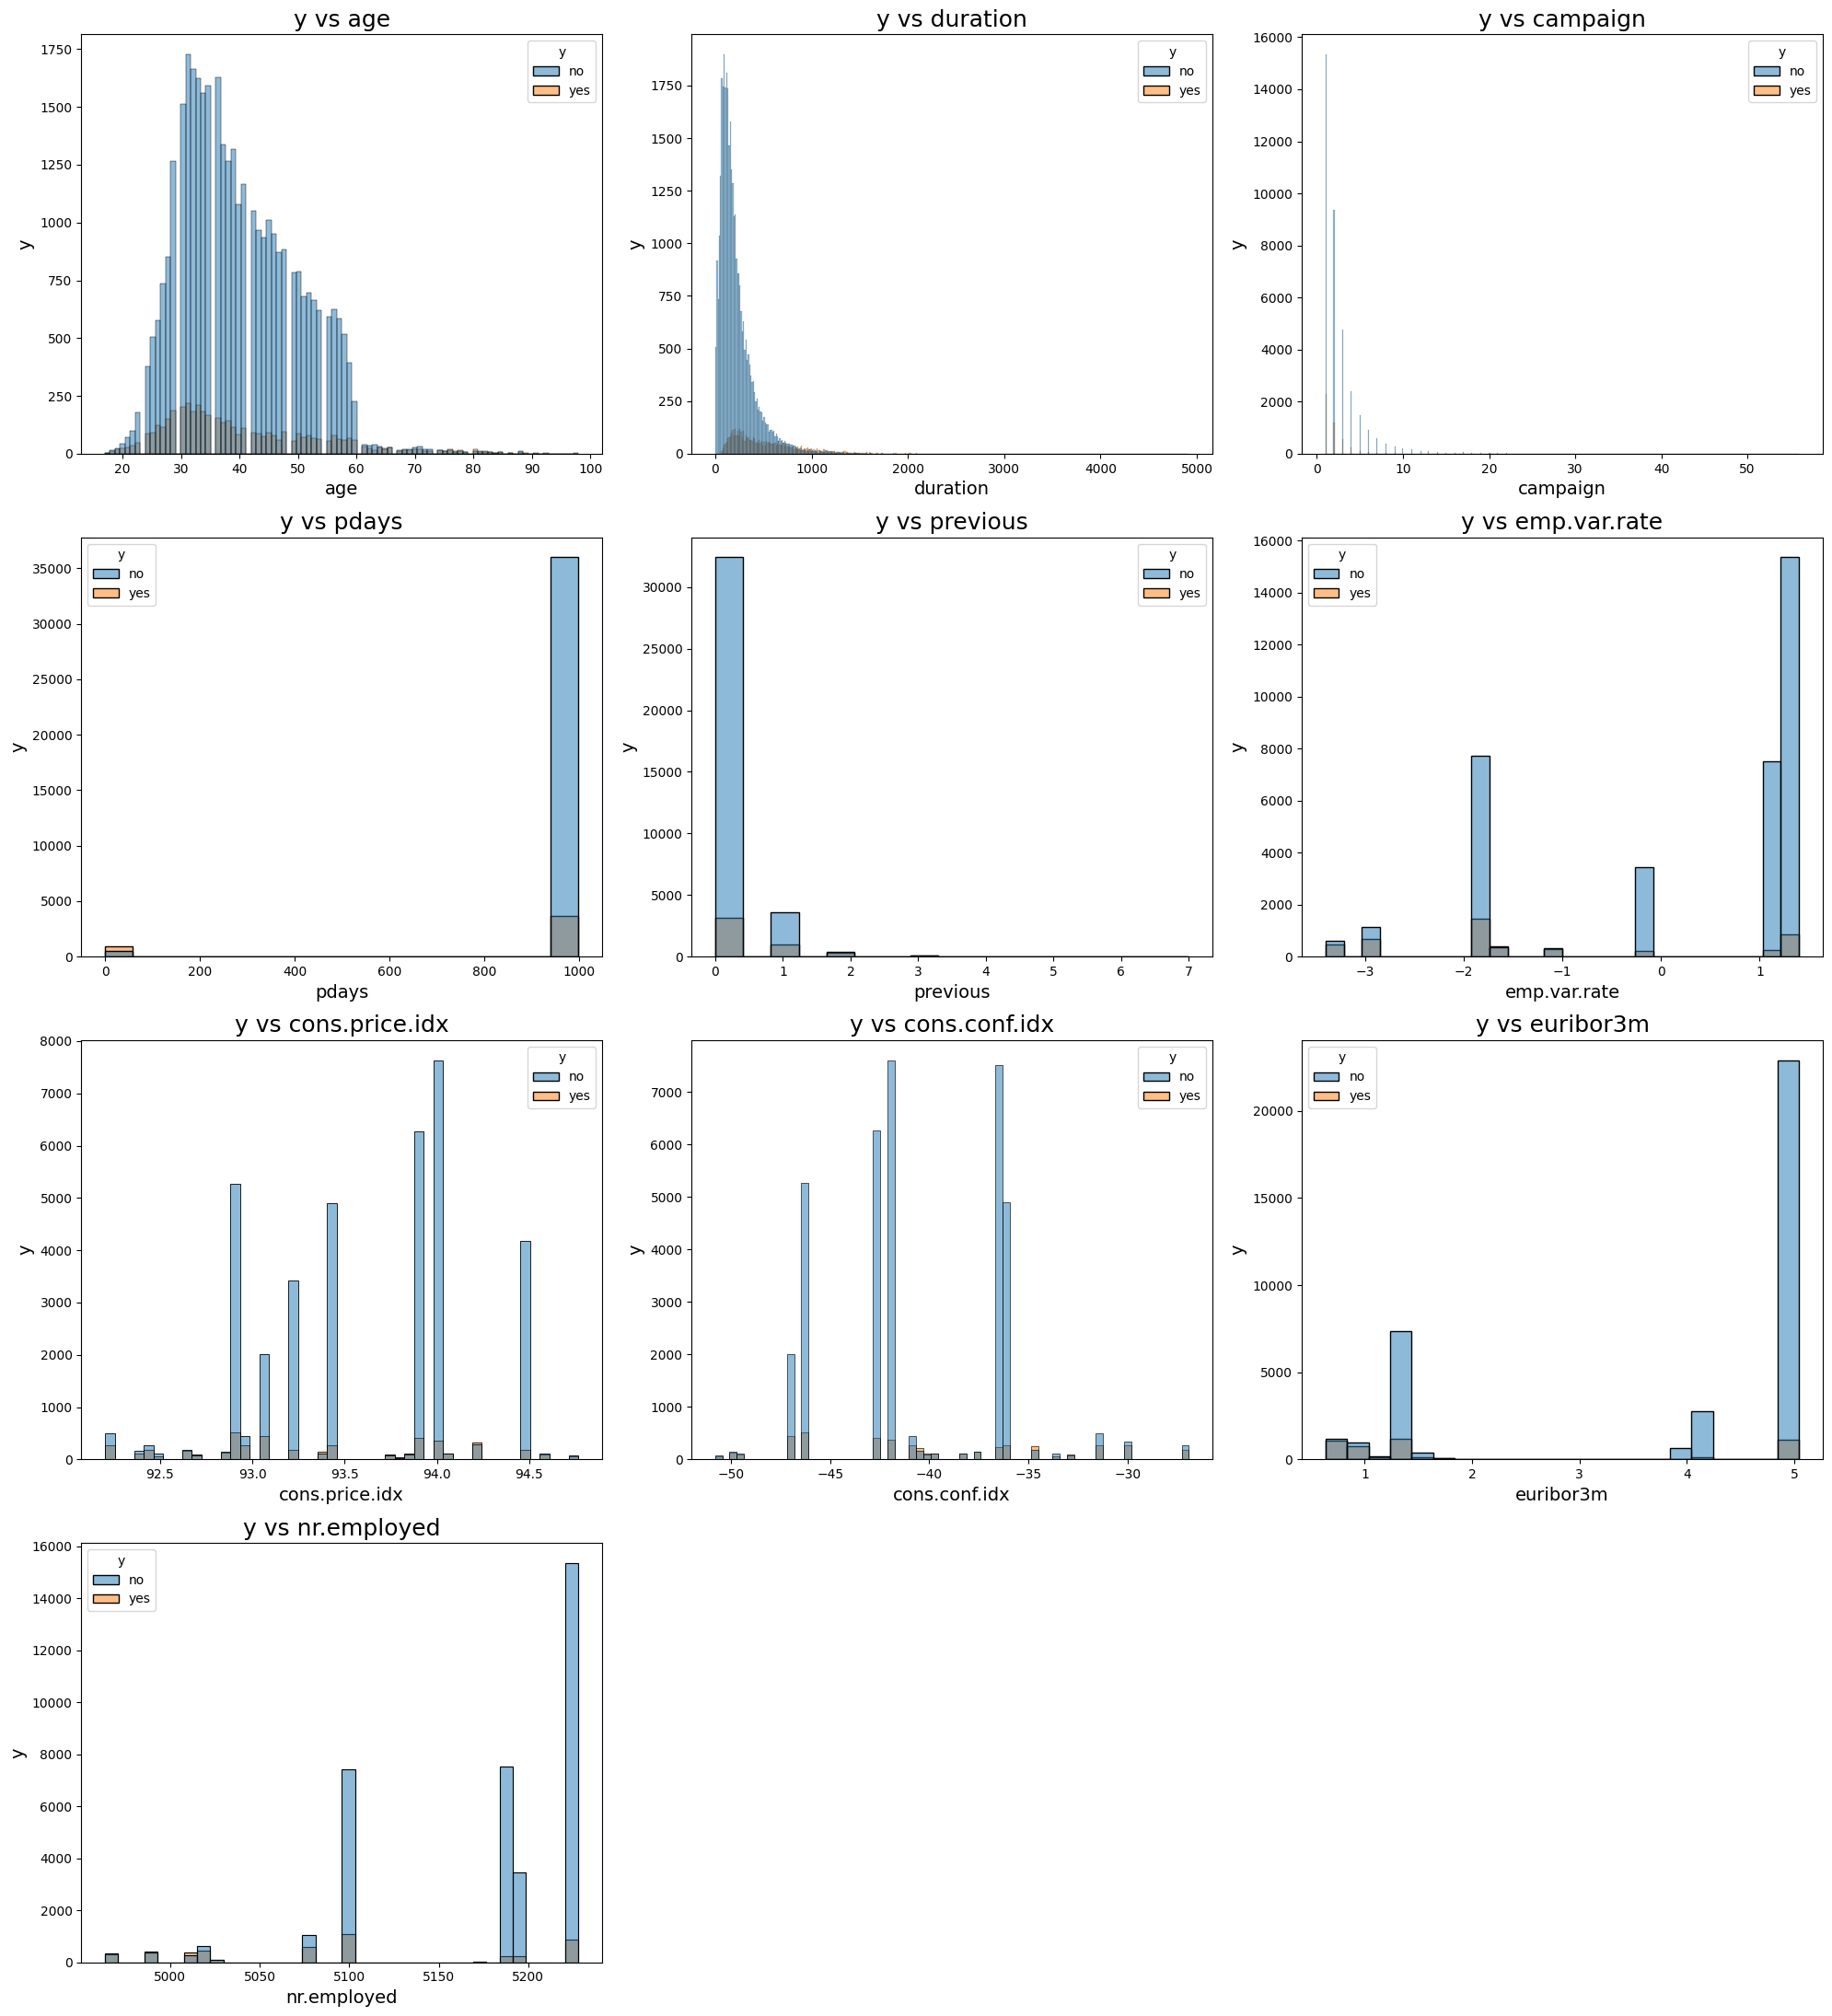

In [23]:
plt.figure(figsize=(20, 22), facecolor='white')
plotnumber = 1

for column in num_data:
    if plotnumber <= 12:
        ax = plt.subplot(4, 3, plotnumber)
        sns.histplot(x=num_data[column], hue=data['y'])
        plt.xlabel(column, fontsize=14)
        plt.ylabel('y', fontsize=14)
        plt.title(f'y vs {column}', fontsize=18)
    plotnumber += 1

plt.tight_layout()
plt.show()


**Bivariate Analysis (Numerical vs Target `y`)**
<h5>
<details>
<summary>y vs age</summary>

- Customers aged **30–40 years** are more likely to subscribe.
- Very low subscription rates for customers above **60 years**.

</details>

<details>
<summary>y vs duration</summary>

- **Call duration** has a strong impact on subscription.
- Longer calls (above **300 seconds**) have a higher chance of `yes`.

</details>

<details>
<summary>y vs campaign</summary>

- Fewer calls (1–3) correlate with better subscription rates.
- Multiple repeated calls (above 5) show declining success.

</details>

<details>
<summary>y vs pdays</summary>

- Most customers have `pdays = 999` (never contacted previously).
- Customers contacted within **100 days** have slightly better chances of subscribing.

</details>

<details>
<summary>y vs previous</summary>

- Higher subscriptions are seen when customers were previously contacted **once or twice**.
- Most customers with no prior contact did not subscribe.

</details>

<details>
<summary>y vs emp.var.rate</summary>

- Higher subscriptions when the employment variation rate is **positive (1.1)**.
- Negative rates correlate with lower subscriptions.

</details>

<details>
<summary>y vs cons.price.idx</summary>

- Subscriptions are relatively higher when CPI is around **93.5**.

</details>

<details>
<summary>y vs cons.conf.idx</summary>

- Higher subscriptions at **-40** and **-45** levels of confidence index.
- Shows the effect of consumer sentiment on marketing success.

</details>

<details>
<summary>y vs euribor3m</summary>

- Higher subscription rates when euribor rates are **low (<2)**.
- Indicates interest rate trends impact customer decisions.

</details>

<details>
<summary>y vs nr.employed</summary>

- Subscriptions are higher when the number of employees is around **5000–5100**.
- Fewer subscriptions at higher employment levels (5200).

</details>
</h5>

# Data preprocessing

**Checking null values**

In [24]:
data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


There are no missing data or null values

**Assigning the unknown values with high frequency values**

In [25]:
data['job'] = data.loc[:,'job'].replace({'unknown':'admin.'})
data['marital'] = data.loc[:,'marital'].replace({'unknown':'married'})
data['education'] = data.loc[:,'education'].replace({'unknown':'university.degree'})
data['default'] = data.loc[:,'default'].replace({'unknown':'no'})
data['housing'] = data.loc[:,'housing'].replace({'unknown':'yes'})
data['loan'] = data.loc[:,'loan'].replace({'unknown':'no'})

**Handle placeholder value in 'pdays'**

In the 'pdays' column, 999 indicates that the client was never contacted before. Since 0 is also being used to represent "never contacted before," we are replacing 999 with 0

In [26]:
data.pdays.value_counts()

,count
pdays,
999,39673
3,439
6,412
4,118
9,64
2,61
7,60
12,58
10,52


In [27]:
data['pdays'] = data['pdays'].replace(999, 0)

In [28]:
data.pdays.value_counts()

,count
pdays,
0,39688
3,439
6,412
4,118
9,64
2,61
7,60
12,58
10,52


**Checking outlines and Impute outliners**

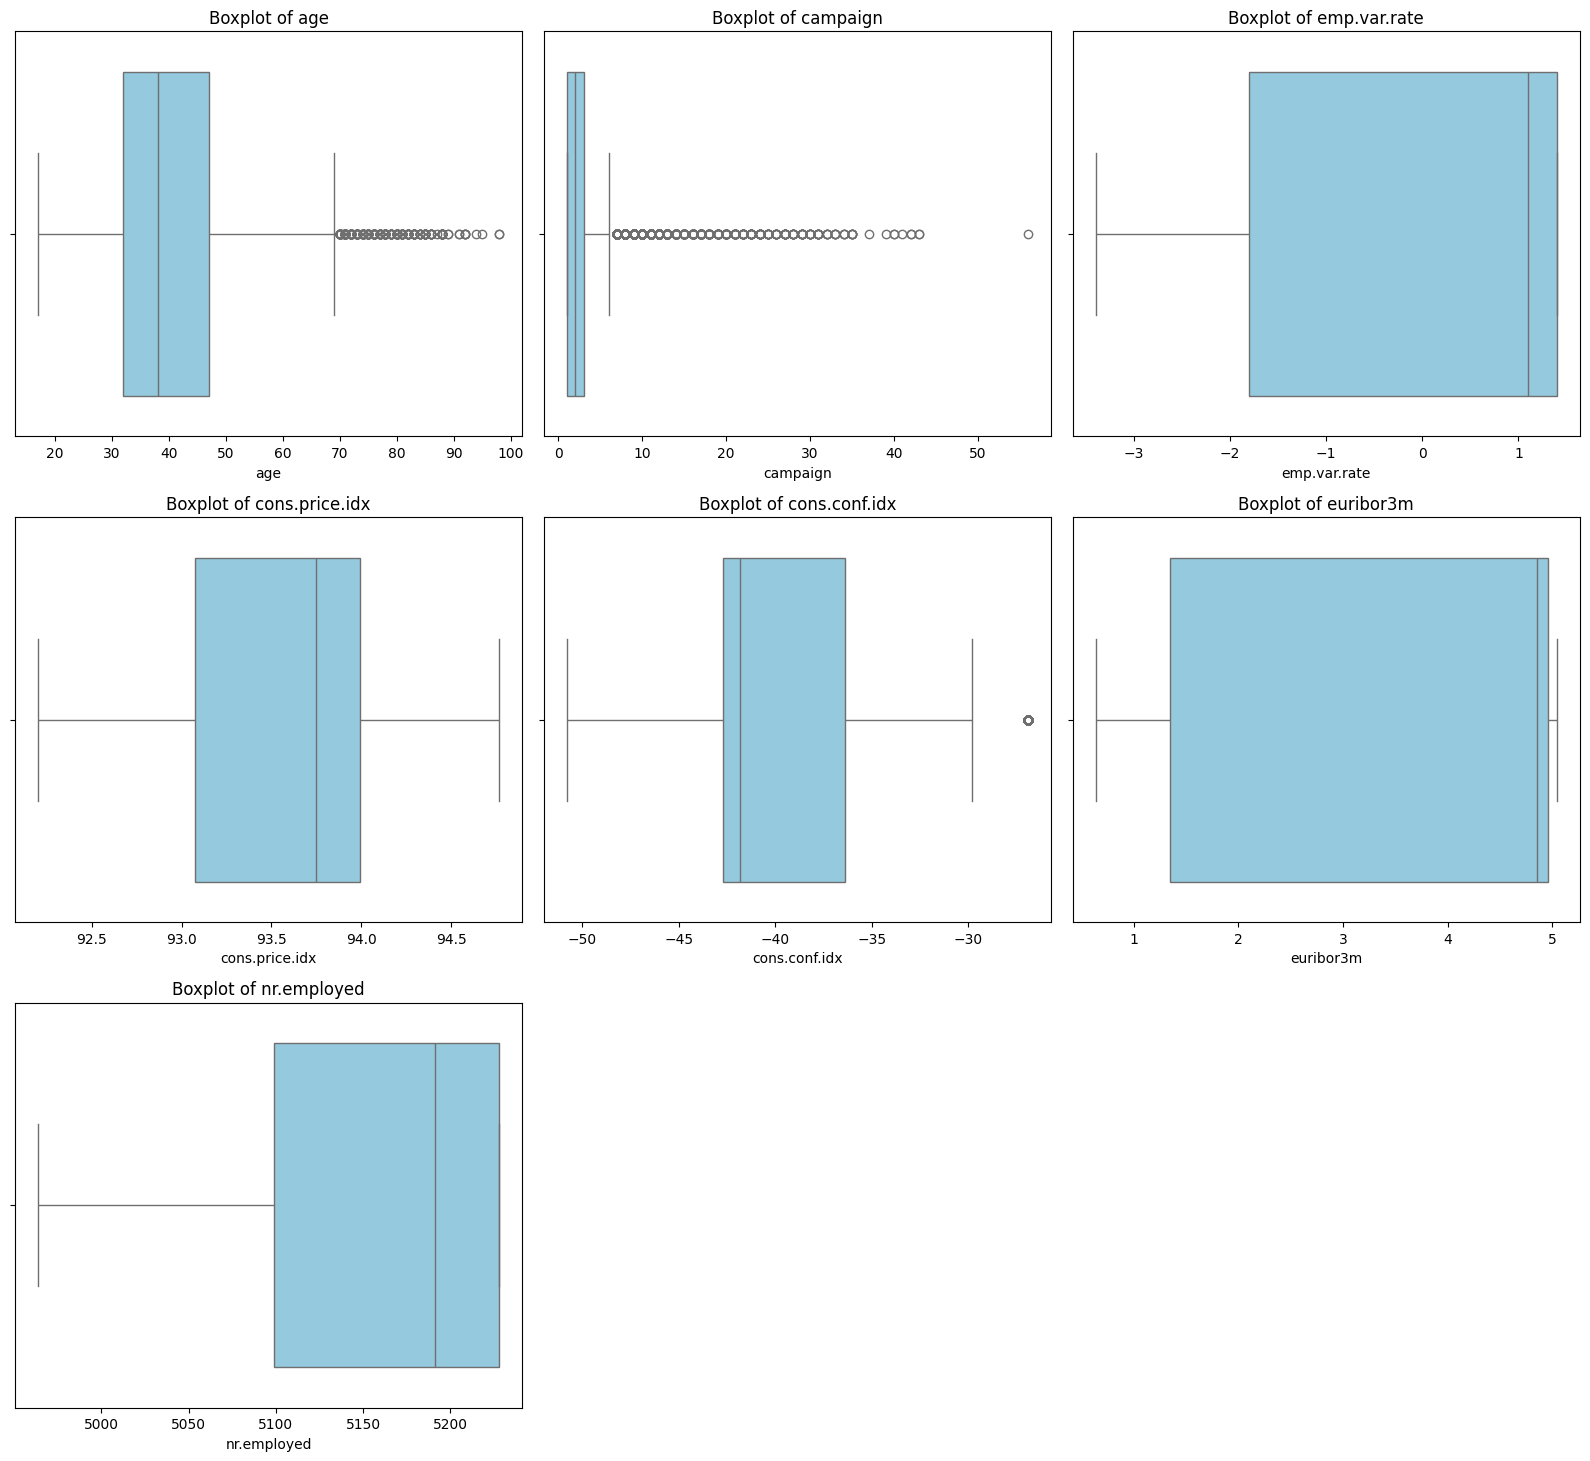

In [29]:
# List of important numeric columns for outlier detection
numeric_cols = ['age', 'campaign',
                'emp.var.rate', 'cons.price.idx',
                'cons.conf.idx', 'euribor3m', 'nr.employed']

# Create boxplots for each numeric column
plt.figure(figsize=(16, 24))  # Adjust figure size for better layout

for idx, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 3, idx)
    sns.boxplot(x=data[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

**Boxplot Overview**
<h5>
<details>
<summary>Age</summary>
Most customers are between **30-50 years**, with few outliers above 70.
</details>

<details>
<summary>Campaign</summary>
Strongly right-skewed; most customers were contacted fewer than 5 times, but some outliers exceed 40.
</details>

<details>
<summary>emp.var.rate</summary>
No significant outliers; values mainly cluster between -2 and 1.
</details>

<details>
<summary>cons.price.idx</summary>
Slightly skewed distribution, with values between **92.5 and 94.5**.
</details>

<details>
<summary>cons.conf.idx</summary>
Spread between **-50 and -30**, with no extreme outliers.
</details>

<details>
<summary>euribor3m</summary>
Majority of values lie between **1 and 5**, with no heavy outliers.
</details>

<details>
<summary>nr.employed</summary>
Ranges mostly between **5000–5200**, with no visible extreme outliers.
</details>
</h5>

**Avoiding Variables:**


1.   **Duration** is excluded due to data leakage (longer calls almost guarantee "yes").
      - Duration = the call duration (in seconds) during the last contact.

      - Higher duration → much higher chance that the client subscribes.

      - It’s almost directly telling the model the outcome (whether the client said "yes" or "no").This creates a problem called data leakage.

     
2.   **pdays** and **previous** are not treated for outliers as they are **discrete variables**, not continuous.



**IQR (Interquartile Range)**

> IQR = Q3 − Q1, it's the difference between the 75th percentile (Q3) and the 25th percentile (Q1) of the data.

I used the **Interquartile Range (IQR) method** to detect and handle outliers for the following continuous variables: **age, campaign, emp.var.rate, cons.price.idx, and cons.conf.idx**.  


>**age**

In [30]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['age'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['age'].quantile(0.25)
Q3 = data['age'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 15.0
Minimum limit: 9.5
Maximum Limit: 69.5


In [31]:
# Impute outlier
data.loc[data['age'] > max_limit,'age']=data['age'].median()

In [32]:
# Filtering the data
data.loc[data['age'] > max_limit]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y




>**campaign**



In [33]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['campaign'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['campaign'].quantile(0.25)
Q3 = data['campaign'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 2.0
Minimum limit: -2.0
Maximum Limit: 6.0


In [34]:
# Replace high outliers with median
data.loc[data['campaign'] > max_limit, 'campaign'] = data['campaign'].median()

# (Optional) Replace low outliers too — if they exist and are valid
data.loc[data['campaign'] < min_limit, 'campaign'] = data['campaign'].median()

In [35]:
# Filtering the data
data.loc[(data['campaign'] < min_limit) | (data['campaign'] > max_limit)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y




> **emp.var.rate**



In [36]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['emp.var.rate'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['emp.var.rate'].quantile(0.25)
Q3 = data['emp.var.rate'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 3.2
Minimum limit: -6.6000000000000005
Maximum Limit: 6.200000000000001


In [37]:
# Filtering the data
data.loc[(data['emp.var.rate'] < min_limit) | (data['emp.var.rate'] > max_limit)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y




> **cons.price.idx**



In [38]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['cons.price.idx'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['cons.price.idx'].quantile(0.25)
Q3 = data['cons.price.idx'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 0.9189999999999969
Minimum limit: 91.69650000000001
Maximum Limit: 95.3725




> **cons.conf.idx**



In [39]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['cons.conf.idx'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['cons.conf.idx'].quantile(0.25)
Q3 = data['cons.conf.idx'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 6.300000000000004
Minimum limit: -52.150000000000006
Maximum Limit: -26.949999999999992


In [40]:
# impute outlier
data.loc[data['cons.conf.idx'] > max_limit,'cons.conf.idx']=data['cons.conf.idx'].median()

In [41]:
# Filtering the data
data.loc[(data['cons.conf.idx'] < min_limit) | (data['cons.conf.idx'] > max_limit)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y


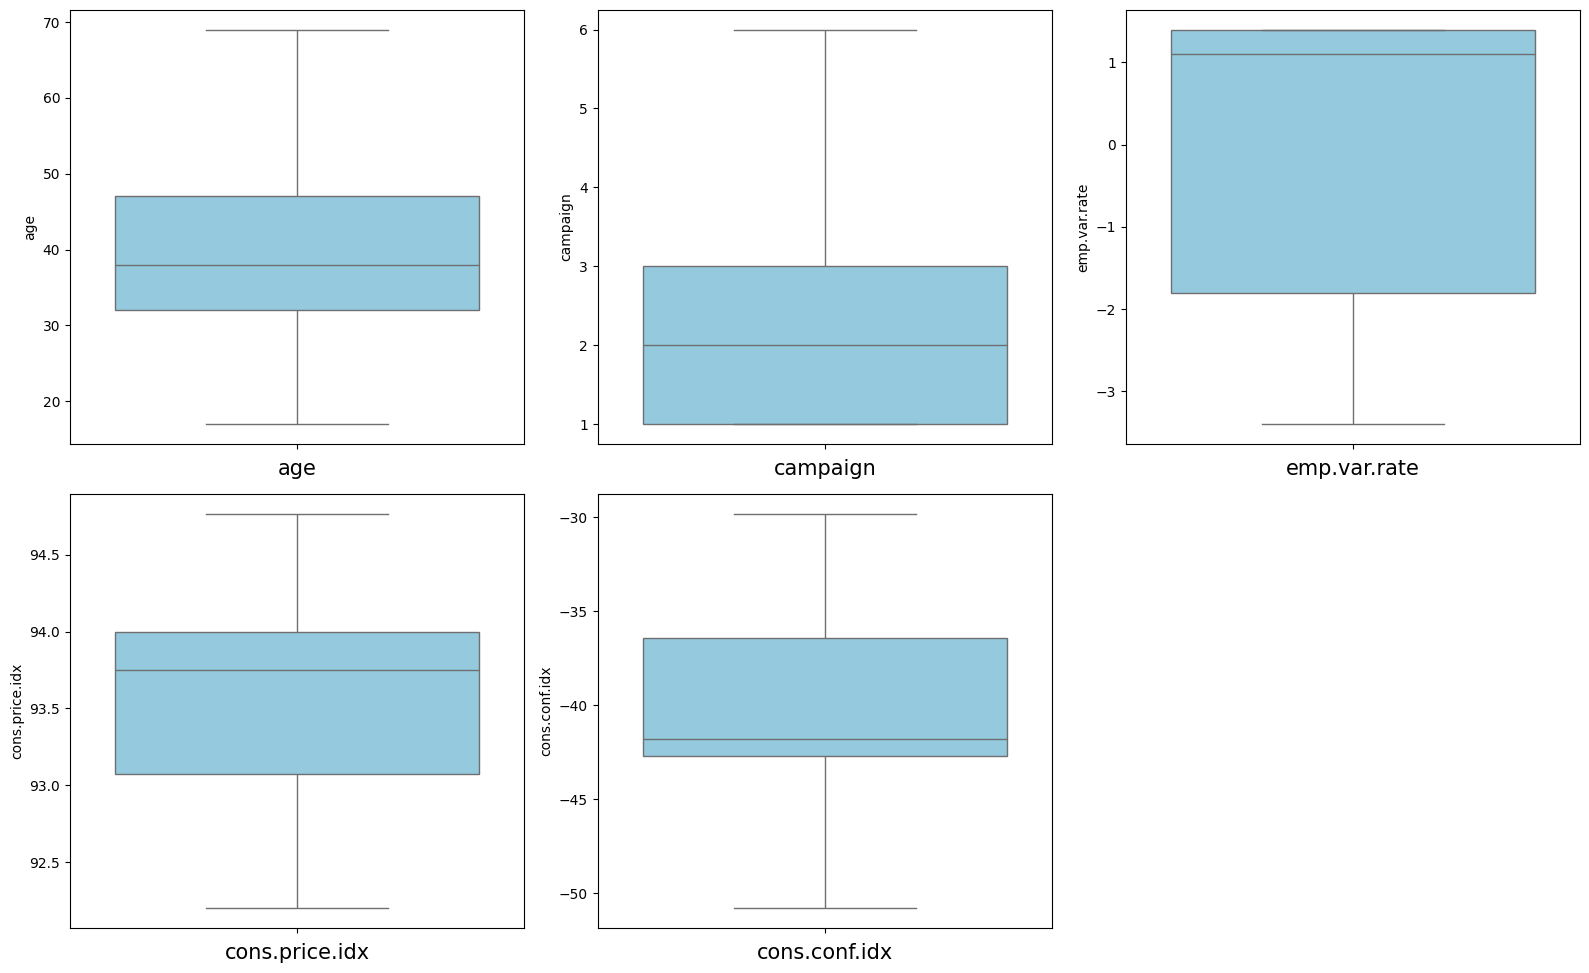

In [42]:
out = data[['age','campaign',
            'emp.var.rate','cons.price.idx','cons.conf.idx']]

plt.figure(figsize=(16,24))
plotno = 1  # counter

for column in out:
    if plotno <= 7:
        plt.subplot(5, 3, plotno)
        sns.boxplot(y=out[column], color='skyblue')  # use 'y' instead of passing directly
        plt.xlabel(column, fontsize=15)
    plotno += 1

plt.tight_layout()
plt.show()

Outlier imputation was successful; no outliers are present in the dataset.

**Encoding categorical data to numerical data**

In [43]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [44]:
## Transfer Data From Categorical to Numerical by using Fit_transform method
data['job']=le.fit_transform(data['job'])
data['marital']=le.fit_transform(data['marital'])
data['education']=le.fit_transform(data['education'])
data['default']=le.fit_transform(data['default'])
data['housing']=le.fit_transform(data['housing'])
data['loan']=le.fit_transform(data['loan'])
data['contact']=le.fit_transform(data['contact'])
data['month']=le.fit_transform(data['month'])
data['day_of_week']=le.fit_transform(data['day_of_week'])
data['poutcome']=le.fit_transform(data['poutcome'])
data['y']=le.fit_transform(data['y'])

In [45]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,261,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,149,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,226,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,151,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,307,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [46]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,38,5,1,5,0,1,0,0,7,0,334,1,0,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,1,1,5,0,0,0,0,7,0,383,1,0,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,1,0,0,7,0,189,2,0,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,9,1,5,0,0,0,0,7,0,442,1,0,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41187,38,5,1,5,0,1,0,0,7,0,239,3,0,1,0,-1.1,94.767,-50.8,1.028,4963.6,0


**Scaling Numerical data**

In [47]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [48]:
data[['age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']]=ss.fit_transform(data[['age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']])

In [49]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,1.706581,3,1,0,0,0,0,1,6,1,0.010471,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0
1,1.810519,7,1,3,0,0,0,1,6,1,-0.421501,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0
2,-0.268244,7,1,3,0,1,0,1,6,1,-0.124520,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0
3,0.043571,0,1,1,0,0,0,1,6,1,-0.413787,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0
4,1.706581,7,1,3,0,0,1,1,6,1,0.187888,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0


In [50]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,-0.164305,5,1,5,0,1,0,0,7,0,0.292025,-0.838424,-0.164012,-0.349494,1,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,1
41184,0.667200,1,1,5,0,0,0,0,7,0,0.481012,-0.838424,-0.164012,-0.349494,1,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,0
41185,1.706581,5,1,6,0,1,0,0,7,0,-0.267225,-0.033496,-0.164012,-0.349494,1,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,0
41186,0.459323,9,1,5,0,0,0,0,7,0,0.708569,-0.838424,-0.164012,-0.349494,1,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,1
41187,-0.164305,5,1,5,0,1,0,0,7,0,-0.074380,0.771432,-0.164012,1.671136,0,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,0


**Balancing Data**

In [51]:
# Calculate the Target Class
data['y'].value_counts()

,count
y,
0,36548
1,4640


The target variable **y** is highly imbalanced, with significantly more "no" responses than "yes" responses. To address this issue and improve model performance, I apply **SMOTE (Synthetic Minority Over-sampling Technique)**. SMOTE generates synthetic samples for the minority class ("yes") by interpolating between existing minority instances, resulting in a balanced dataset. This helps prevent model bias toward the majority class and enhances the predictive power of our model.

In [52]:
# Create X & Y Variable for SMOTE
X = data.drop('y',axis=1)
Y = data['y']

In [53]:
from imblearn.over_sampling import SMOTE # import SMOTE from oversampling
smote = SMOTE() # Make a variable for SMOTE
X_smot, y_smot = smote.fit_resample(X, Y)

In [54]:
y_smot.value_counts()

,count
y,
0,36548
1,36548


Now data class is **balanced**

In [55]:
# Create a data frame using Two SMOTE values
data= pd.concat([X_smot, y_smot],axis=1)

In [56]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,1.706581,3,1,0,0,0,0,1,6,1,0.010471,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
1,1.810519,7,1,3,0,0,0,1,6,1,-0.421501,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
2,-0.268244,7,1,3,0,1,0,1,6,1,-0.124520,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
3,0.043571,0,1,1,0,0,0,1,6,1,-0.413787,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
4,1.706581,7,1,3,0,0,1,1,6,1,0.187888,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73091,-0.164305,5,0,0,0,0,0,0,5,4,-0.403361,-0.033496,-0.164012,-0.349494,1,-1.197935,-1.265761,-2.119356,-1.129071,-0.940281,1
73092,2.303332,4,0,3,0,0,0,0,1,1,0.564118,-0.786386,-0.164012,-0.218861,0,-1.898153,-2.374889,2.103150,-1.592665,-1.257233,1
73093,-0.585606,0,2,5,0,1,1,0,5,3,0.136706,-0.838424,-0.164012,-0.349494,1,-1.197935,-0.357036,1.331294,-1.711973,-2.191481,1
73094,-0.746029,0,1,6,0,0,0,0,3,1,-0.142259,0.771432,-0.164012,-0.349494,1,-1.134279,1.104525,0.082703,-1.579960,-2.428157,1


In [57]:
# Save the cleaned/preprocessed dataset to a CSV
data.to_csv("preprocessed_portuguese_bank.csv", index=False)

# Feature Selection

**Checking co-relation**

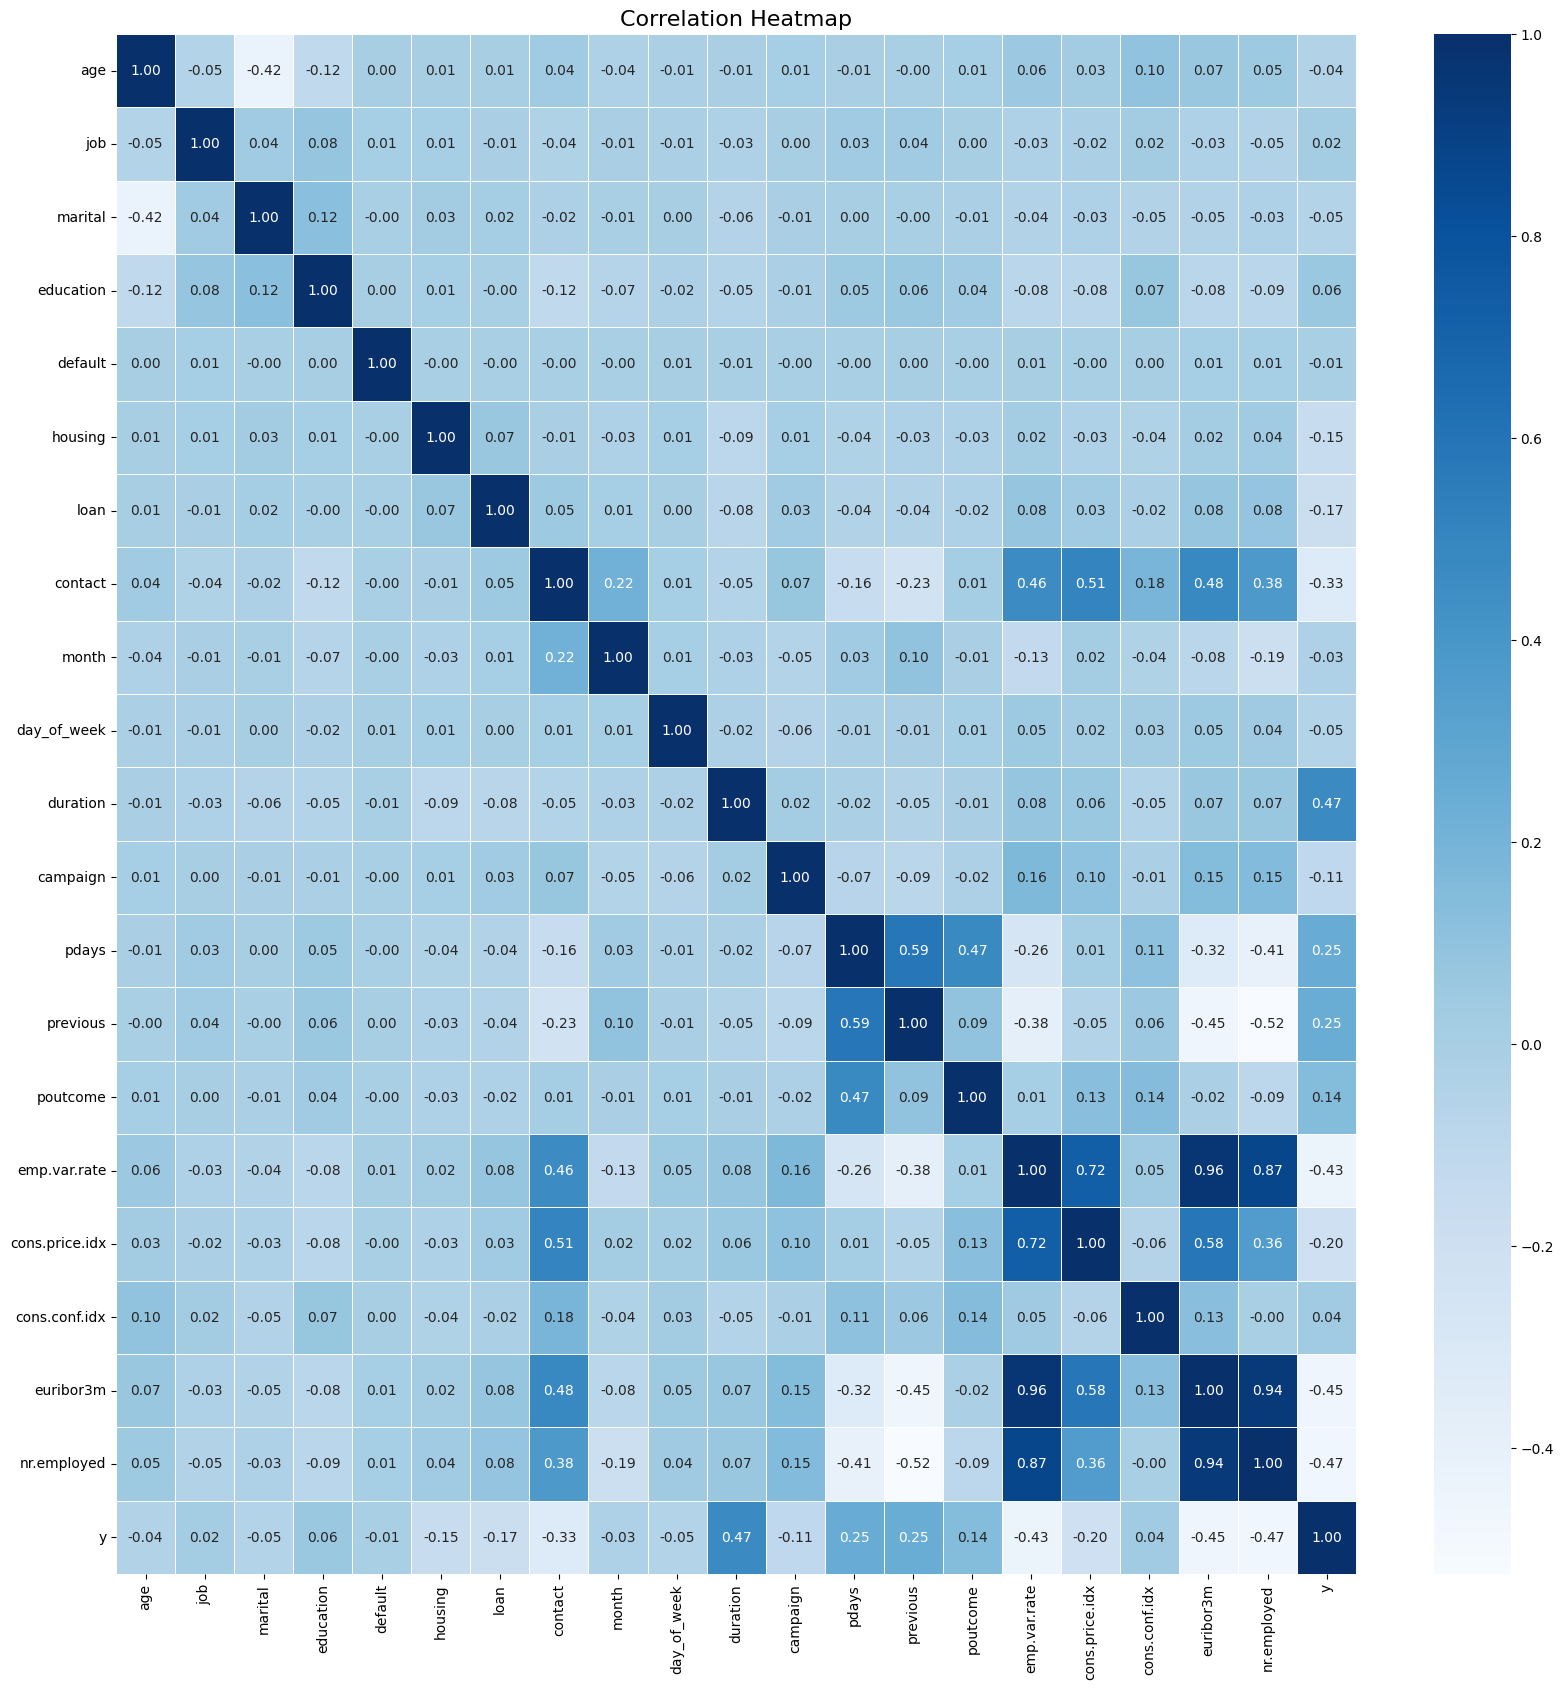

In [59]:
# check the co-relation between each variable and with target class.
plt.figure(figsize=(20, 20))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="Blues", cbar=True, linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

Found that **'emp.var.rate'** , **'nr.employed'** & **'euribor3m'** are highly corelated with each other ,so we can remove anyt two of them.

In [60]:
print(data.duplicated().sum())

24


In [61]:
import numpy as np
# Create correlation matrix
corr_matrix = data.corr().abs()
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("Highly correlated features to consider dropping:", to_drop)

Highly correlated features to consider dropping: ['euribor3m', 'nr.employed']


**Creating X and Y**

In [62]:
# Create dependent and independent variable
X = data.drop(['y','euribor3m','nr.employed'],axis=1)    # Independent Variable
y = data['y']                                            # Dependent variable

In [63]:
y.value_counts()

,count
y,
0,36548
1,36548


# Model Development

In [64]:
# Splitting the data into train & test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=15)

In [65]:
from sklearn.metrics import accuracy_score,classification_report,f1_score,precision_score,recall_score

### **Logistic Regression**

In [66]:
from sklearn.linear_model import LogisticRegression
log= LogisticRegression(random_state=15)
log.fit(x_train,y_train)

LogisticRegression(random_state=15)

In [67]:
y_pred = log.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 0, 1])

**Model Evaluation**

In [68]:
# Accuracy Score for training data
y_pr_log_train=log.predict(x_train)
acc_lr_train = accuracy_score(y_train,y_pr_log_train)
acc_lr_train

0.8753298024117107

The model achieved a **training accuracy** of **87.53%**, indicating a strong ability to learn patterns from the training dataset.

In [69]:
# Accuracy Score for testing
acc_log = accuracy_score(y_test,y_pred)
acc_log

0.8719047836198641

The model obtained a **testing accuracy** of **87.19%**, which is close to the training accuracy, showing good generalization and no signs of overfitting.

In [70]:
# Classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87     10971
           1       0.86      0.88      0.87     10958

    accuracy                           0.87     21929
   macro avg       0.87      0.87      0.87     21929
weighted avg       0.87      0.87      0.87     21929



In [71]:
print("Precission Score : " ,precision_score(y_test,y_pred))
print("recall_score : " ,recall_score(y_test,y_pred))
print("f1_score : " ,f1_score(y_test,y_pred))

Precission Score :  0.8640872129389688
recall_score :  0.8824603029749954
f1_score :  0.8731771186058062


For **Class 0 (No)**, the model achieved a precision of **0.88**, recall of **0.86**, and an F1-score of **0.87**.
For **Class 1 (Yes)**, the precision was **0.86**, recall **0.88**, and F1-score **0.87**.
The overall accuracy is **87%**, with macro and weighted averages both at **0.87**, suggesting consistent performance across both classes with slightly better recall for identifying customers likely to subscribe.

**Hyperparameter Tuning**

In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
# Create Logistic Regression model
log_reg = LogisticRegression(random_state=15, solver='liblinear')

In [74]:
# Define parameter grid for tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],       # Regularization strength
    'penalty': ['l1', 'l2'],            # L1 (Lasso) or L2 (Ridge)
    'class_weight': [None, 'balanced']  # Handle class imbalance
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,                # 5-fold cross-validation
    n_jobs=-1,           # Use all cores
    verbose=1            # Show progress
)

# Fit the grid search to the training data
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(random_state=15, solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'penalty': ['l1', 'l2']},
             scoring='accuracy', verbose=1)

In [75]:
# Display the best parameters and best CV score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l1'}
Best Cross-Validation Score: 0.8764829883873807


In [76]:
# Get the best model
best_log_reg = grid_search.best_estimator_

In [77]:
# Predict using the tuned model
y_pred_tuned = best_log_reg.predict(x_test)
y_pred_tuned

array([0, 1, 1, ..., 0, 0, 1])

In [78]:
# Calculate accuracy of tuned model
acc_hyp_log = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy of Tuned Logistic Regression Model: {acc_hyp_log:.4f}")

Accuracy of Tuned Logistic Regression Model: 0.8725


The tuned Logistic Regression model achieved an accuracy of **87.25%** on the test dataset. This is a slight improvement compared to the base model (**87.19%**)

### **K-Nearest Neighbour**

In [79]:
from sklearn.neighbors import KNeighborsClassifier

In [80]:
# Taking optimal k to determine how many nearest neighbors to create
error_rate = []
for i in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    pred_i = knn.predict(x_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

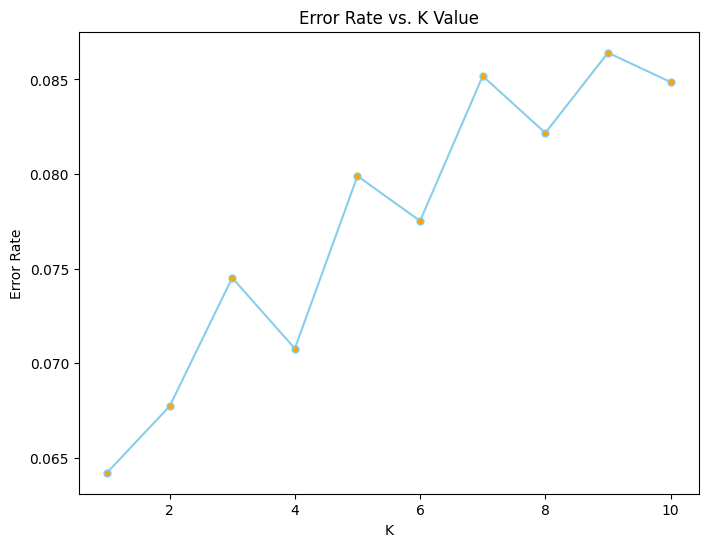

In [81]:
# Plot the k-value and error rate
plt.figure(figsize=(8,6))
plt.plot(range(1,11),error_rate,color='skyblue', linestyle='solid',
         marker='o',markerfacecolor='orange', markersize=5)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

The **Error Rate vs. K Value** plot shows that the model achieves its lowest error at **K = 1**, indicating the best performance with a smaller number of neighbors. As K increases, the error rate gradually rises, suggesting reduced model accuracy and a tendency toward underfitting. Therefore, **K = 1** is the most optimal choice for this dataset.

However, **K = 1** might overfit since it only considers the closest neighbor, making the model sensitive to noise. The error at **K = 4** is still low and stable, which is ideal for a base model.

In [82]:
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(x_train,y_train)
y_pred_knn = knn.predict(x_test)

**Model Evaluation**

In [83]:
# Printing Accuracy Score for Training Data
y_pr_knn_train=knn.predict(x_train)
acc_knn_train = accuracy_score(y_train,y_pr_knn_train)
acc_knn_train

0.9581957120800516

In [84]:
# Calculate Accuracy for testing data
acc_knn = accuracy_score(y_test,y_pred_knn)
acc_knn

0.9292261389028228

The KNN model achieved a training accuracy of **95.81%** and a testing accuracy of **92.92%**, indicating a slight generalization gap but no severe overfitting. This shows the model performs well on both training and unseen data.

In [85]:
# Classification report
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93     10971
           1       0.89      0.97      0.93     10958

    accuracy                           0.93     21929
   macro avg       0.93      0.93      0.93     21929
weighted avg       0.93      0.93      0.93     21929



For **class 0**, the model achieved **97%** precision and **89%** recall, meaning it correctly identifies most negative cases but misses some. For **class 1**, it achieved **89%** precision and **97%** recall, indicating strong detection of positive cases with a few false positives. Both classes have an F1-score of **0.93**, demonstrating a balanced performance between precision and recall.

**Hyperparameter Tuning**

In [86]:
hyperpara = [{'n_neighbors':[2,3,4,5,6,7,8,9,10],'weights':['distance','uniform']}]   # define n_neighbors & weights values
grid = GridSearchCV(estimator = KNeighborsClassifier(),param_grid = hyperpara,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                          'weights': ['distance', 'uniform']}],
             scoring='accuracy')

In [87]:
grid.best_params_

{'n_neighbors': 2, 'weights': 'distance'}

In [88]:
Knn_smote = KNeighborsClassifier(n_neighbors=5,weights="distance")    # make a variable for KNeighborsClassifier
Knn_smote.fit(x_train,y_train)
Y_prd_knn_hyp = grid.predict(x_test)

# finding accuracy
acc_knn_hyp = accuracy_score(y_test,Y_prd_knn_hyp)
acc_knn_hyp

0.9357927858087464

The tuned KNN model with **n_neighbors=2** and **weights='distance'** achieved **93.58%** accuracy, outperforming the base model (**92.92%**) by better capturing local patterns through distance-based weighting.

### **Support Vector Classifier**

In [89]:
from sklearn.svm import SVC
svm = SVC(random_state=42)  # Create a variable of support Vector
svm.fit(x_train,y_train)
y_pr_svm = svm.predict(x_test)
y_pr_svm

array([0, 1, 1, ..., 0, 0, 1])

**Model Evaluation**

In [90]:
# Printing Accuracy Score for Training Data
y_pr_svm_train=svm.predict(x_train)
acc_svm_train = accuracy_score(y_train,y_pr_svm_train)
acc_svm_train

0.8979224891043055

In [91]:
# Calculate Accuracy testing
acc_svm = accuracy_score(y_test,y_pr_svm)
acc_svm

0.8908294951890191

The SVC model achieved a **training accuracy** of **89.79%** and a **testing accuracy** of **89.08%**, indicating good performance but a noticeable gap, suggesting slight overfitting.

In [92]:
# Classification report
print(classification_report(y_test,y_pr_svm))

              precision    recall  f1-score   support

           0       0.93      0.84      0.89     10971
           1       0.86      0.94      0.90     10958

    accuracy                           0.89     21929
   macro avg       0.89      0.89      0.89     21929
weighted avg       0.89      0.89      0.89     21929



For **class 0**, the model achieved **93%** **precision** and **84%** **recall**, meaning it predicts negative cases well but misses some. For **class 1**, it achieved **86% precision** and **94% recall**, showing strong detection of positive cases. Both classes have **F1-scores close to 0.89–0.90**, reflecting balanced performance.

**Hyperparameter Tuning**

In [93]:
from sklearn.model_selection import RandomizedSearchCV

In [94]:
# Reduced and smarter parameter space
param_dist = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

# Random Search
svm_random = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_dist,
    n_iter=6,        # Only 6 random combinations
    cv=2,            # 2-fold CV
    verbose=3,
    scoring='accuracy',
    n_jobs=-1
)

svm_random.fit(x_train, y_train)

Fitting 2 folds for each of 6 candidates, totalling 12 fits


RandomizedSearchCV(cv=2, estimator=SVC(random_state=42), n_iter=6, n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10], 'gamma': [0.1, 0.01],
                                        'kernel': ['rbf', 'linear']},
                   scoring='accuracy', verbose=3)

In [95]:
# print best parameter after tuning
print(svm_random.best_params_)

# print how our model looks after hyper-parameter tuning
print(svm_random.best_estimator_)

{'kernel': 'rbf', 'gamma': 0.1, 'C': 10}
SVC(C=10, gamma=0.1, random_state=42)


In [96]:
svm_hyp =SVC(C=10, gamma=0.1,random_state=42,kernel='rbf') # Create a variable of support Vector
svm_hyp.fit(x_train,y_train)
y_hyp_svm = svm_hyp.predict(x_test)
acc_hyp_svm = accuracy_score(y_test,y_hyp_svm) # Calculate Accuracy
acc_hyp_svm

0.9373432441059784

The tuned SVC model with **rbf kernel**, **C=10**, and **gamma=0.1** achieved **93.73%** accuracy, a notable improvement over the base model’s **89.08%.**

### **Decision Tree**

In [97]:
from sklearn.tree import DecisionTreeClassifier
d_tree = DecisionTreeClassifier(random_state=42) # Make a variable of decision tree
d_tree.fit(x_train,y_train)

y_pr_dtree = d_tree.predict(x_test) # Predict x_test

**Model Evaluation**

In [98]:
# Printing Accuracy Score for Training Data
y_pr_dt_train=d_tree.predict(x_train)
acc_dt_train = accuracy_score(y_train,y_pr_dt_train)
acc_dt_train

1.0

In [99]:
# Calculate Accuracy testing
acc_dtree = accuracy_score(y_test,y_pr_dtree)
acc_dtree

0.9030051529937526

The Decision Tree model achieved **100% training accuracy**, indicating it perfectly fits the training data, but the **testing accuracy** is **90.30%**, suggesting some overfitting.

In [100]:
# Classification report
print(classification_report(y_test,y_pr_dtree))

              precision    recall  f1-score   support

           0       0.91      0.90      0.90     10971
           1       0.90      0.91      0.90     10958

    accuracy                           0.90     21929
   macro avg       0.90      0.90      0.90     21929
weighted avg       0.90      0.90      0.90     21929



For **class 0**, the model recorded **91% precision** and **90% recall**, while for **class 1**, it achieved **90% precision** and **91% recall**. Both classes have an **F1-score of 0.90**, reflecting balanced predictions across classes.

**Hyperparameter Tuning**

In [101]:
# Creating dictionary of hyperparameters for randomized search
params = {
    "criterion": ["gini", "entropy"],    # quality of split
    "splitter": ["best", "random"],      # searches the features for a split
    "max_depth": list(range(1, 20)),      # depth of tree from 1 to 19
    "min_samples_split": [2, 3, 4],       # minimum samples required to split internal node
    "min_samples_leaf": list(range(1, 20)), # minimum samples required at a leaf node
}

# Create the Decision Tree model
tree = DecisionTreeClassifier(random_state=4)

# Setup RandomizedSearchCV instead of GridSearchCV
tree_cv = RandomizedSearchCV(tree, params, n_iter=50, scoring="accuracy", n_jobs=-1, verbose=1, cv=3, random_state=42)

# Fit the model
tree_cv.fit(x_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=4),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10, 11,
                                                             12, 13, 14, 15, 16,
                                                             17, 18, 19],
                                        'min_samples_split': [2, 3, 4],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='accuracy', verbose=1)

In [102]:
# Get the best parameters
best_params = tree_cv.best_params_

# Print the best parameters
print(f"Best parameters: {best_params}")

Best parameters: {'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 12, 'criterion': 'gini'}


In [103]:
#Passing best parameter to decision tree
dtree_hyp=DecisionTreeClassifier(criterion='entropy',max_depth=12,min_samples_leaf= 4,min_samples_split=2,splitter='best',random_state=4)
dtree_hyp.fit(x_train,y_train) # Training model with best parameter
y_hyp_tree=dtree_hyp.predict(x_test)
acc_hyp_tree=accuracy_score(y_test,y_hyp_tree) #Checking accuracy
acc_hyp_tree

0.9047836198641069

The tuned Decision Tree model with **max_depth=11**, **min_samples_split=4**, and **min_samples_leaf=13** achieved an improved **test accuracy** of **90.47%**, slightly better than the **base model’s 90.30%**. The tuning effectively reduced overfitting while maintaining balanced performance across classes.

# Model Comparison Report

In [110]:
Report = pd.DataFrame({'model':['Log_Regression','K_nearest','Support vector','Decision tree'],
                       'Training Accuracy':[acc_lr_train,acc_knn_train,acc_svm_train,acc_dt_train],
                       'Test Accuracy':[acc_log,acc_knn,acc_svm,acc_dtree],
                       'HyperParameter Score':[acc_hyp_log,acc_knn_hyp,acc_hyp_svm,acc_hyp_tree,
                               ],
                       'F1 score':[f1_score(y_test,y_pred),f1_score(y_test,y_pred_knn),f1_score(y_test,y_pr_svm),
                          f1_score(y_test,y_pr_dtree)]
             })

Report

,model,Training Accuracy,Test Accuracy,HyperParameter Score,F1 score
0,Log_Regression,0.875330,0.871905,0.872452,0.873177
1,K_nearest,0.958196,0.929226,0.935793,0.932156
2,Support vector,0.897922,0.890829,0.937343,0.895786
3,Decision tree,1.000000,0.903005,0.904784,0.903673


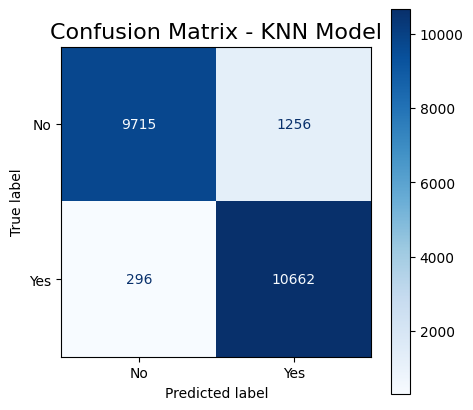

In [113]:
# Considering KNN as best model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, knn.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])

# Plot
plt.figure(figsize=(5, 5))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Confusion Matrix - KNN Model', fontsize=16)
plt.show()

The KNN model demonstrates strong performance, correctly predicting **9,715** customers as not subscribing and **10,662** customers as subscribing, with only **1**,**256** false positives and **296** false negatives.



> Thus, **KNN** is the best model here because it offers the best balance between **accuracy (92.9%)** and **F1-score (93.2%)**, making it more reliable than **SVC** for this dataset despite SVC’s slightly higher tuned score.



# Challenges Faced and Techniques Applied

**Presence of Unknown or Missing Values**: Several columns like job, education, default, housing, and loan had "unknown" values.

> To address this, for variables like education, replaced 'unknown' with the mode (most frequent category).



**High Correlation with Target Variable (Data Leakage)**: Variables like duration had a very high correlation with the outcome (y), but it’s not realistic for prediction (known only after the call).

> These were resolved by dropping duration from model training to avoid data leakage and ensure a realistic predictive setup. Highly correlated features to consider dropping: ['euribor3m', 'nr.employed'].



**Categorical Variables Handling**: Many categorical features like job, marital, education, poutcome, etc.

> Label Encoding was applied for efficient model processing.



# Suggestions to the Bank Marketing Team

<h5>
<details>
<summary>1. Focus on High-Conversion Segments</summary>

> Target age groups between **30–50 years**, as they form the majority of the potential customers. Prioritize customers with stable jobs like **admin, technician, blue-collar, and management** roles, as they have shown higher positive responses.
</details>

<details>
<summary>2. Optimize Contact Strategy</summary>

> Avoid excessive calls (campaign variable), as too many attempts reduce the chances of subscription. Schedule calls during **May–August** , when response rates are relatively higher.
</details>

<details>
<summary>3. Leverage Historical Campaign Outcomes</summary>

> Customers with past campaign success (poutcome = success) should be prioritized, as they are more likely to respond positively. Use **previous and pdays** variables carefully to avoid contacting uninterested customers too frequently.
</details>

<details>
<summary>4. Financial Product Insights</summary>

> Target customers with **housing or personal loans**, as they might be interested in additional financial products. Customize offers for customers with **higher emp.var.rate** and favorable economic indices.
</details>

<details>
<summary>5. Enhance Marketing Communication Channels</summary>

> Focus on **cellular contact methods** as they have shown better results than telephone.
</details>

<details>
<summary>6. Customer Segmentation and Personalization</summary>

> Use predictive models (like Logistic Regression or KNN) to **segment customers** into likely responders and non-responders. Design personalized marketing strategies based on the model’s predictions.
</details>

<details>
<summary>7. Reduce Reliance on Duration</summary>

> Do not use **call duration** as a primary success indicator during campaigns, as it can lead to misleading performance measures.
</details>
</h5>

# Project Summary

```
 The Portuguese Bank Marketing project aimed to predict term deposit subscriptions using customer demographics,
 campaign details, and socio-economic indicators. Exploratory analysis revealed that customers aged 30–50, with university
 degrees, and contacted via cellular phones are more likely to subscribe. Among the models tested, KNN achieved the highest
 performance with an accuracy of 92.9% and F1-score of 93.2%, making it the most reliable choice for this dataset.
```

